<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/Monte_Carlo_Simulation_for_Superconducting_Phase_Prediction_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install cupy-cuda12x

Initializing simulation utilizing backend architecture GPU
Executing deterministic TDGL relaxation at 0.6 K...


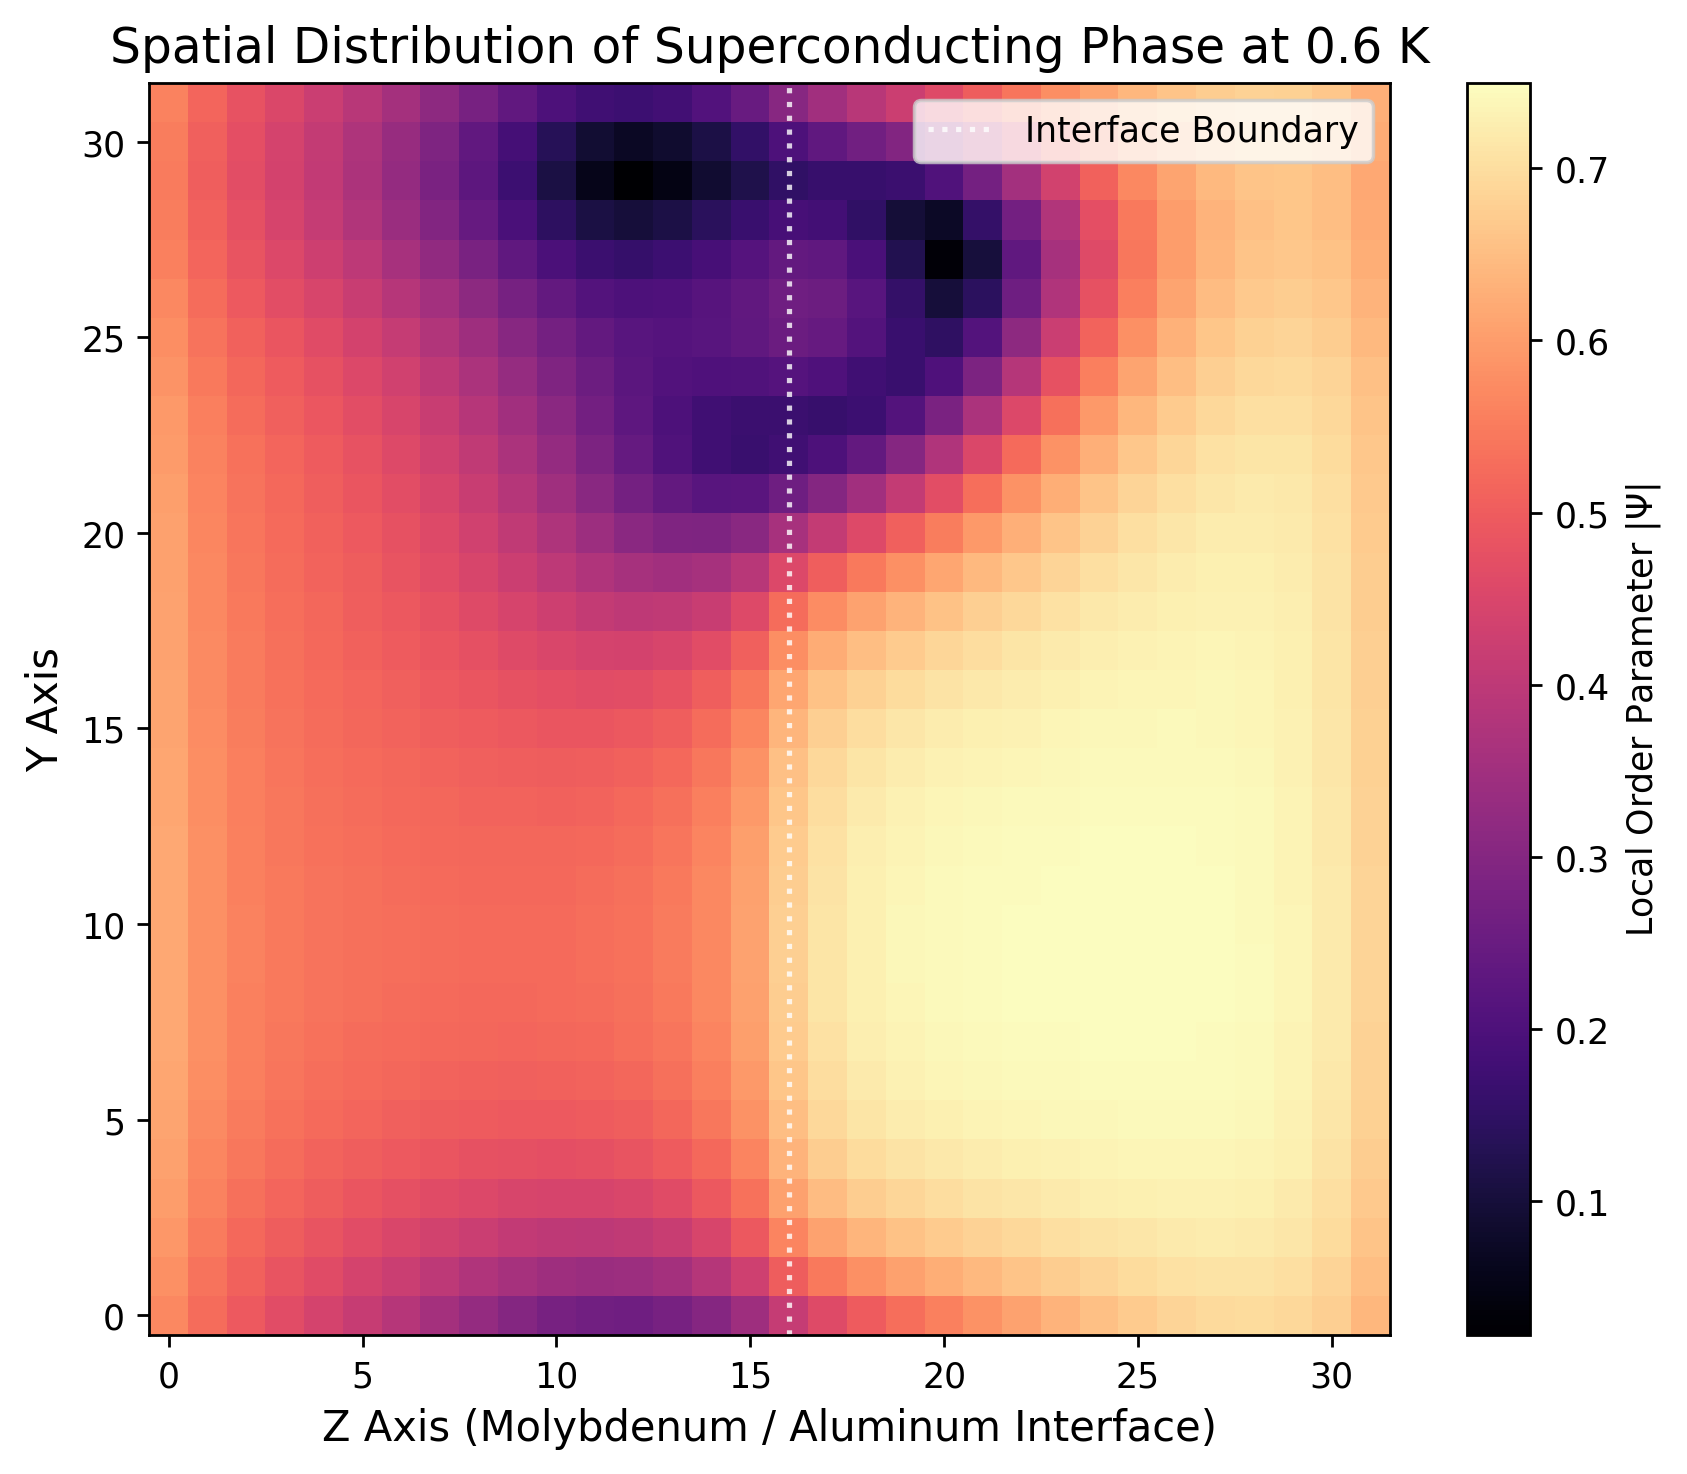


Macroscopic phase evaluation and spatial rendering successfully completed.


In [7]:
"""This script simulates the superconducting transition using deterministic gradient relaxation.

The architecture evaluates a continuous Time Dependent Ginzburg and Landau
equation to strictly enforce macroscopic phase coherence across the simulated
bilayer geometry while entirely bypassing stochastic geometric fragmentation.
"""

import math
from typing import Tuple, List

try:
    import cupy as xp
    _test_allocation = xp.array([1.0])
    DEVICE_TYPE = "GPU"
except Exception:
    import numpy as xp
    DEVICE_TYPE = "CPU"

import matplotlib.pyplot as plt
import matplotlib as mpl

# Global typographical configurations for scientific visualization
mpl.rcParams['figure.dpi'] = 250
mpl.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
mpl.rcParams['font.weight'] = 'normal'

# =============================================================================
# Global Control Knobs
# =============================================================================
LATTICE_DIMENSIONS: Tuple[int, int, int] = (32, 32, 32)
T_INTRINSIC_MO: float = 0.9
T_INTRINSIC_AL: float = 1.18
GL_BETA_COEFF: float = 1.0
GL_GAMMA_COEFF: float = 2.0
RELAXATION_TIME_STEP: float = 0.01
HEATMAP_TARGET_TEMP: float = 0.6
TOTAL_RELAXATION_ITERATIONS: int = 4000
# =============================================================================

class BilayerSuperconductorSim:
    """Simulates the superconducting phase transition using a deterministic TDGL equation.

    Attributes:
        shape (Tuple[int, int, int]): Dimensions of the three dimensional simulation lattice.
        t_mo (float): Intrinsic critical temperature of the Molybdenum layer.
        t_al (float): Intrinsic critical temperature of the Aluminum layer.
        beta (float): The quartic coefficient of the macroscopic free energy.
        gamma (float): The stiffness coefficient for the spatial gradient term.
        xp (module): The active hardware agnostic numerical backend module.
    """

    def __init__(
        self,
        shape: Tuple[int, int, int] = LATTICE_DIMENSIONS,
        t_mo: float = T_INTRINSIC_MO,
        t_al: float = T_INTRINSIC_AL,
        beta: float = GL_BETA_COEFF,
        gamma: float = GL_GAMMA_COEFF
    ):
        """Initializes the thermodynamic parameters and generates the continuous complex field."""
        self.shape = shape
        self.t_mo = t_mo
        self.t_al = t_al
        self.beta = beta
        self.gamma = gamma
        self.xp = xp

        real_part = self.xp.random.randn(*shape).astype(self.xp.float64)
        imag_part = self.xp.random.randn(*shape).astype(self.xp.float64)
        self.psi = (real_part + 1j * imag_part) * 0.1

        self.mid_z = shape[2] // 2

    def _calculate_local_alpha(self, current_t: float) -> xp.ndarray:
        """Calculates the temperature dependent alpha coefficient across the metallic interface."""
        alpha = self.xp.zeros(self.shape, dtype=self.xp.float64)
        alpha[:, :, :self.mid_z] = (current_t - self.t_mo)
        alpha[:, :, self.mid_z:] = (current_t - self.t_al)
        return alpha

    def run_tdgl_relaxation(self, current_t: float, dt: float, iterations: int):
        """Performs deterministic gradient descent updates to strictly minimize free energy."""
        alpha = self._calculate_local_alpha(current_t)

        for _ in range(iterations):
            continuous_laplacian = (
                self.xp.roll(self.psi, 1, axis=0) + self.xp.roll(self.psi, -1, axis=0) +
                self.xp.roll(self.psi, 1, axis=1) + self.xp.roll(self.psi, -1, axis=1) +
                self.xp.roll(self.psi, 1, axis=2) + self.xp.roll(self.psi, -1, axis=2) -
                6.0 * self.psi
            )

            free_energy_derivative = (
                alpha * self.psi +
                self.beta * (self.xp.abs(self.psi)**2) * self.psi -
                self.gamma * continuous_laplacian
            )

            self.psi = self.psi - dt * free_energy_derivative

    def get_spatial_slice(self) -> xp.ndarray:
        """Extracts a central two dimensional planar cross section of the order parameter."""
        mid_x = self.shape[0] // 2
        slice_2d = self.xp.abs(self.psi[mid_x, :, :])

        if hasattr(slice_2d, 'get'):
            return slice_2d.get()
        return slice_2d

def analyze_and_visualize() -> None:
    """Executes the thermodynamic simulation utilizing a deterministic relaxation protocol."""
    print(f"Initializing simulation utilizing backend architecture {DEVICE_TYPE}")
    sim = BilayerSuperconductorSim()

    print(f"Executing deterministic TDGL relaxation at {HEATMAP_TARGET_TEMP} K...")
    sim.run_tdgl_relaxation(
        current_t=HEATMAP_TARGET_TEMP,
        dt=RELAXATION_TIME_STEP,
        iterations=TOTAL_RELAXATION_ITERATIONS
    )

    spatial_data = sim.get_spatial_slice()

    plt.figure(figsize=(7, 6))
    plt.imshow(spatial_data, cmap='magma', origin='lower', aspect='auto')
    plt.colorbar(label=r'Local Order Parameter $|\Psi|$')
    plt.title(f'Spatial Distribution of Superconducting Phase at {HEATMAP_TARGET_TEMP} K', fontsize=14)
    plt.xlabel('Z Axis (Molybdenum / Aluminum Interface)', fontsize=12)
    plt.ylabel('Y Axis', fontsize=12)
    plt.axvline(x=LATTICE_DIMENSIONS[2] // 2, color='white', linestyle=':', alpha=0.8, label='Interface Boundary')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_and_visualize()
    print("\nMacroscopic phase evaluation and spatial rendering successfully completed.")

Selected backend: GPU 0: Tesla T4
Linearized layered-GL transition estimate: 1.138090 K
Running the one-dimensional Newton warming sweep across 30 temperatures.
Sweep convergence: 30/30 states.
Running the full spatial relaxation at 0.600 K.

Simulation summary
Backend: GPU 0: Tesla T4
Linearized model Tc: 1.138090 K
Linearized eigenvalue residual: -2.577e-15
Target temperature: 0.600000 K
Converged: True
Iterations completed: 4850
Energy-increase checks: 0
Mean order-parameter amplitude: 6.588094e-01
Mean condensate density: 4.421877e-01
Phase coherence: 1.000000000
Interface phase locking: 1.000000000
Interface amplitude mismatch: 5.950945e-02
Residual supercurrent RMS: 2.877290e-07
Reduced free-energy density: -1.048174e-01
Mo condensate density: 3.278281e-01
Al condensate density: 5.565473e-01


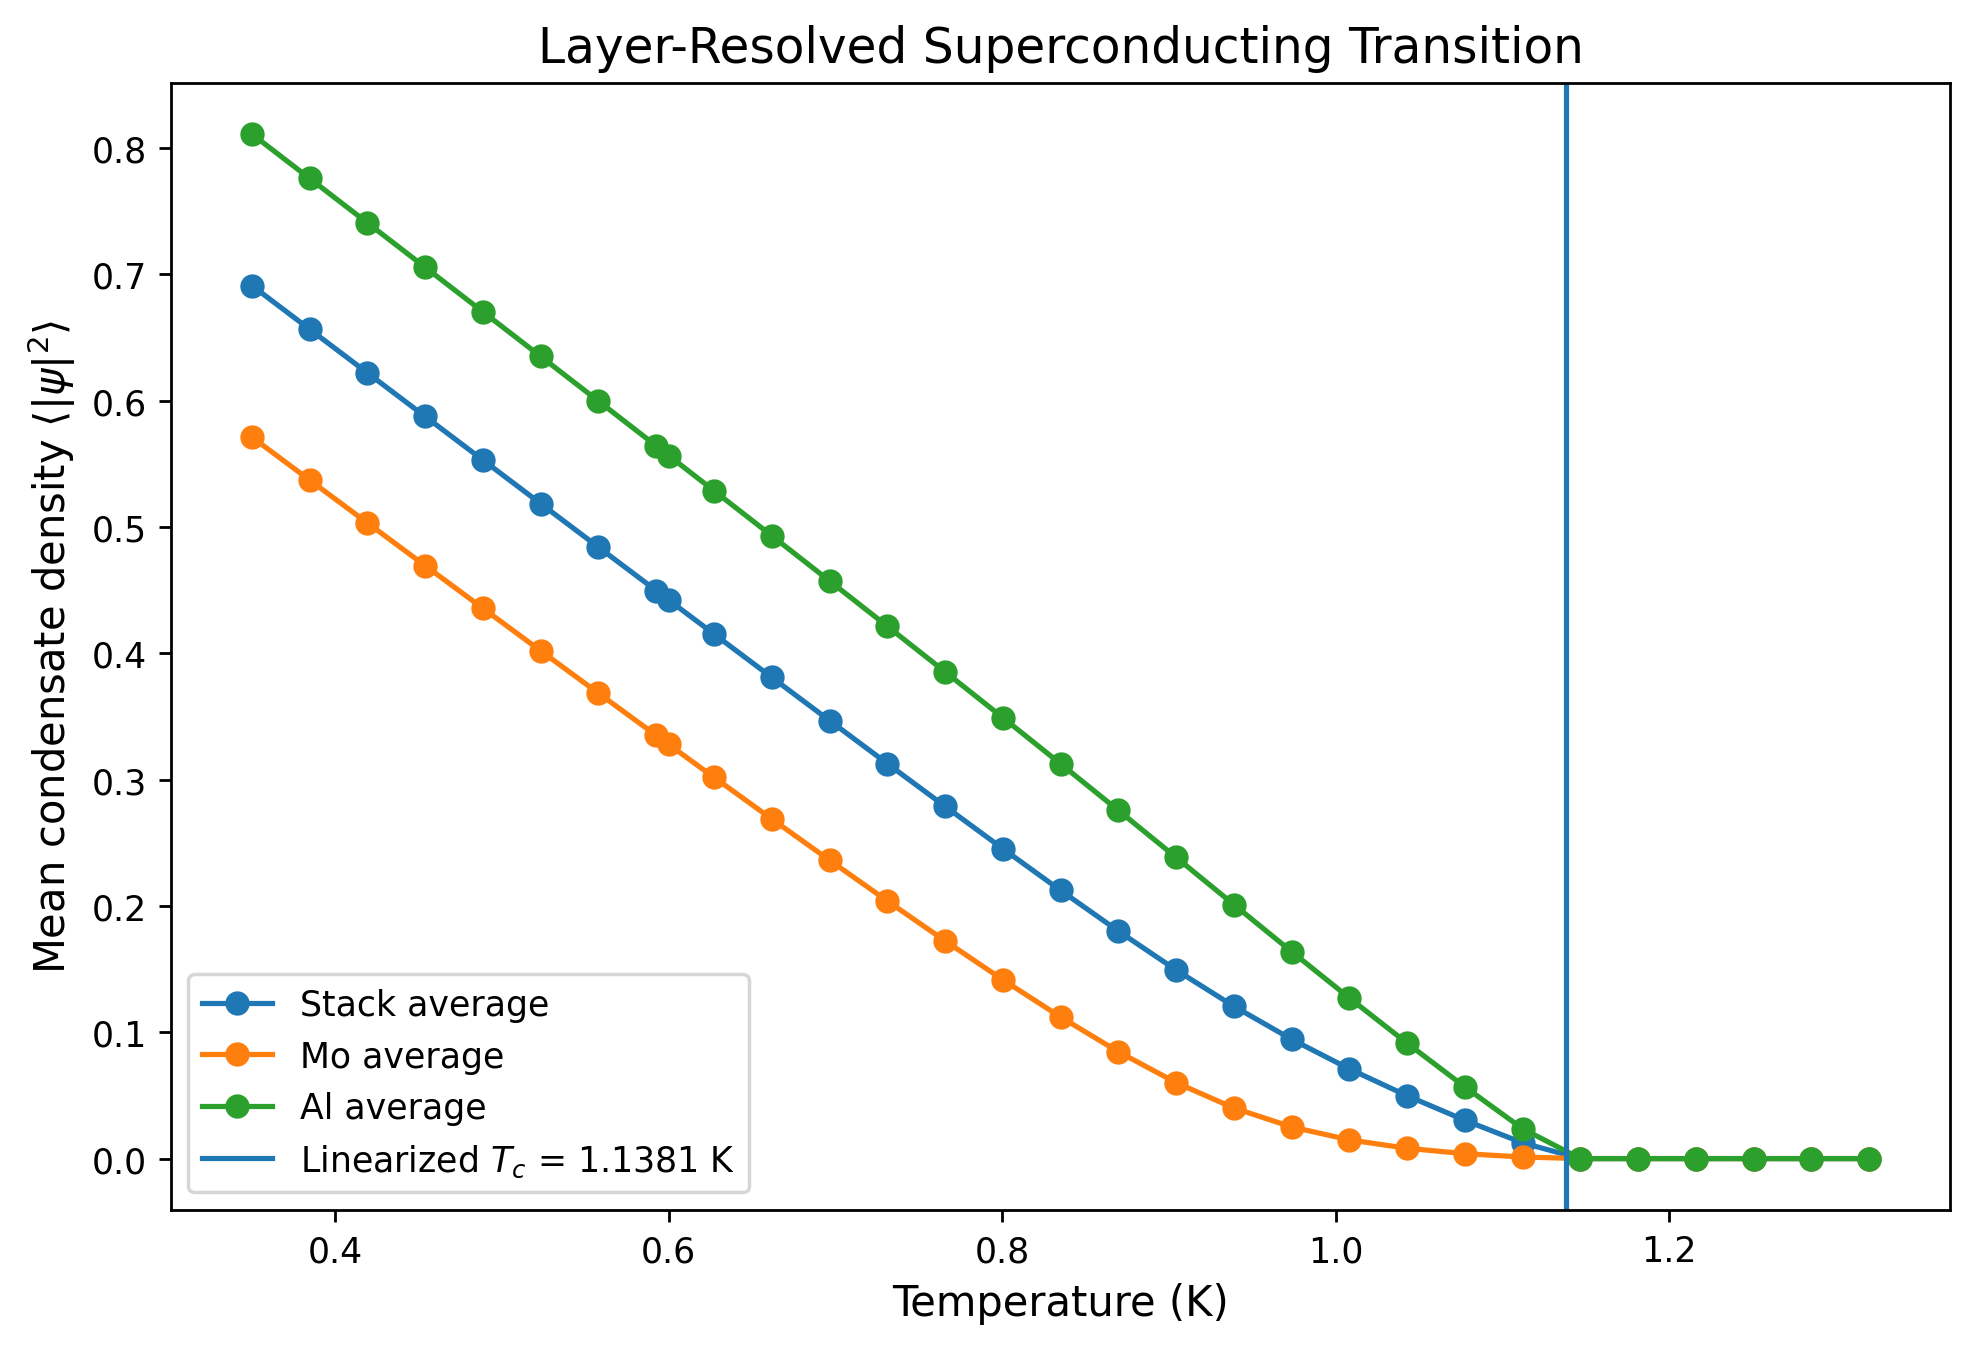

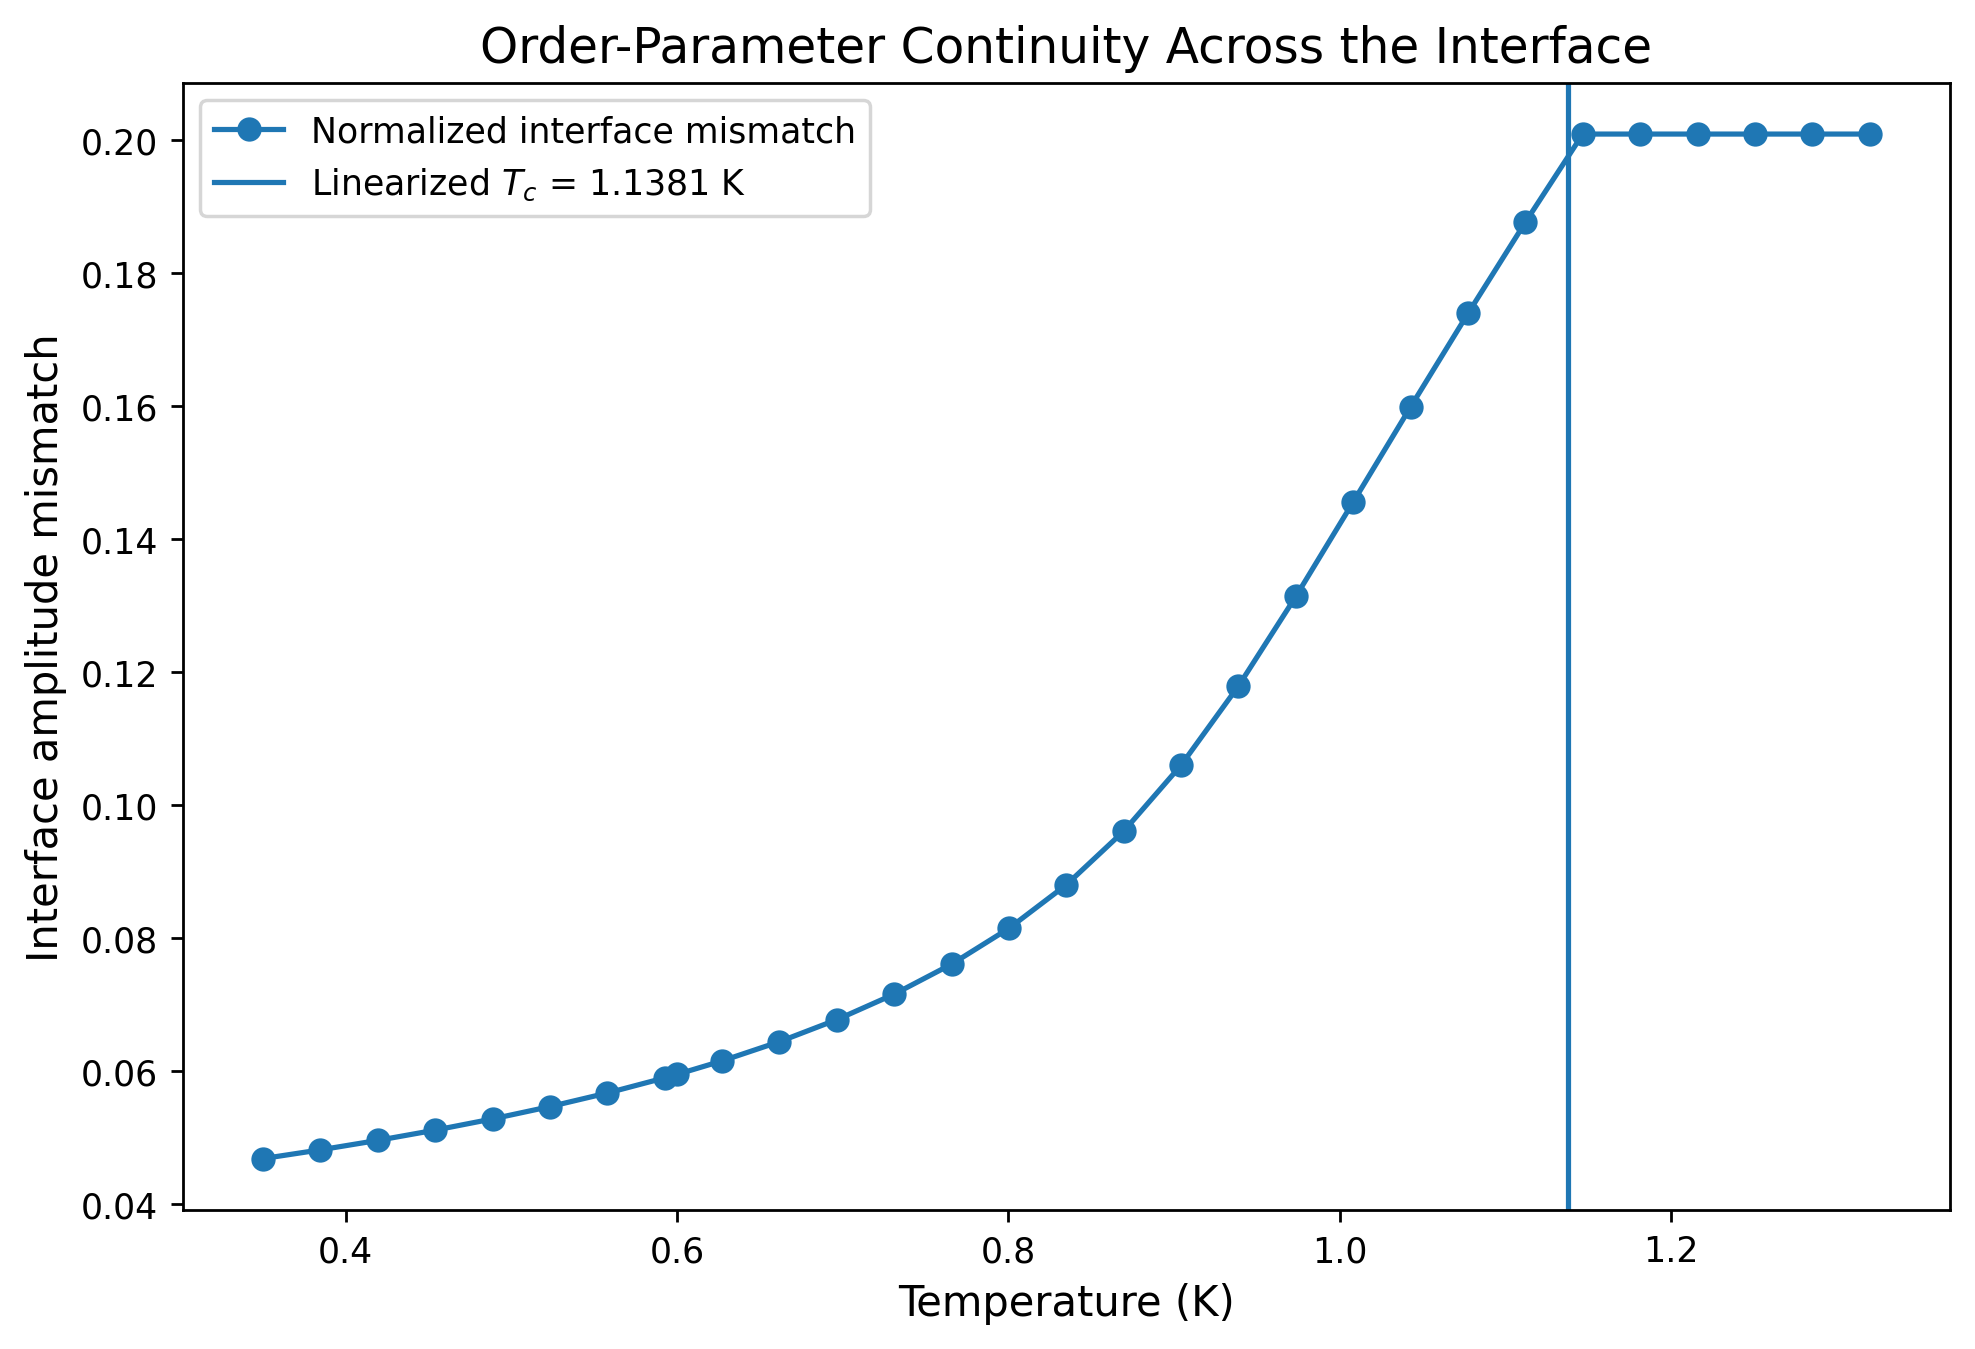

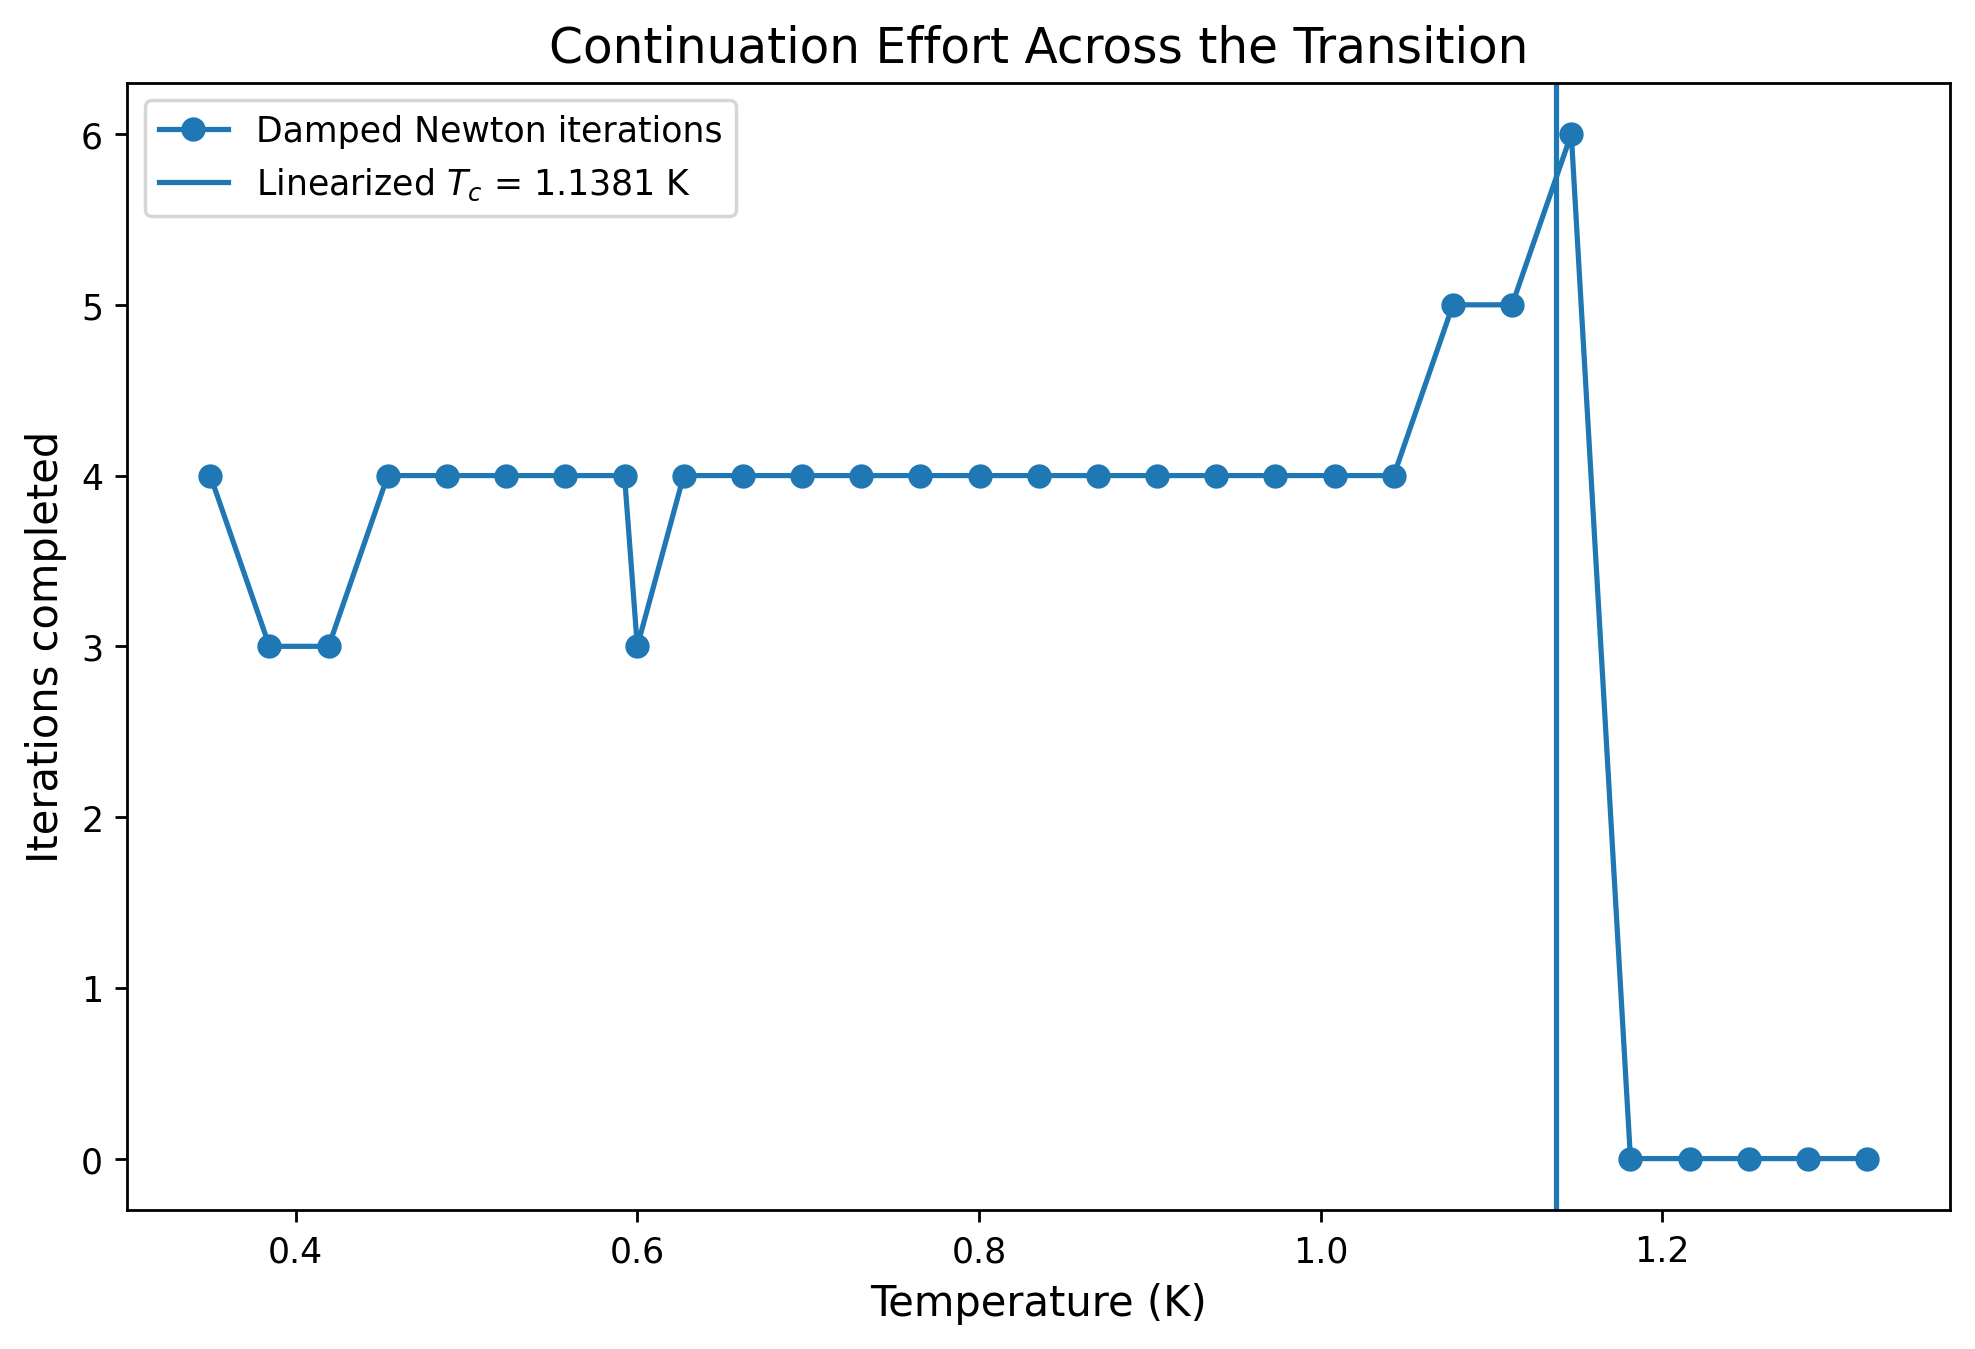

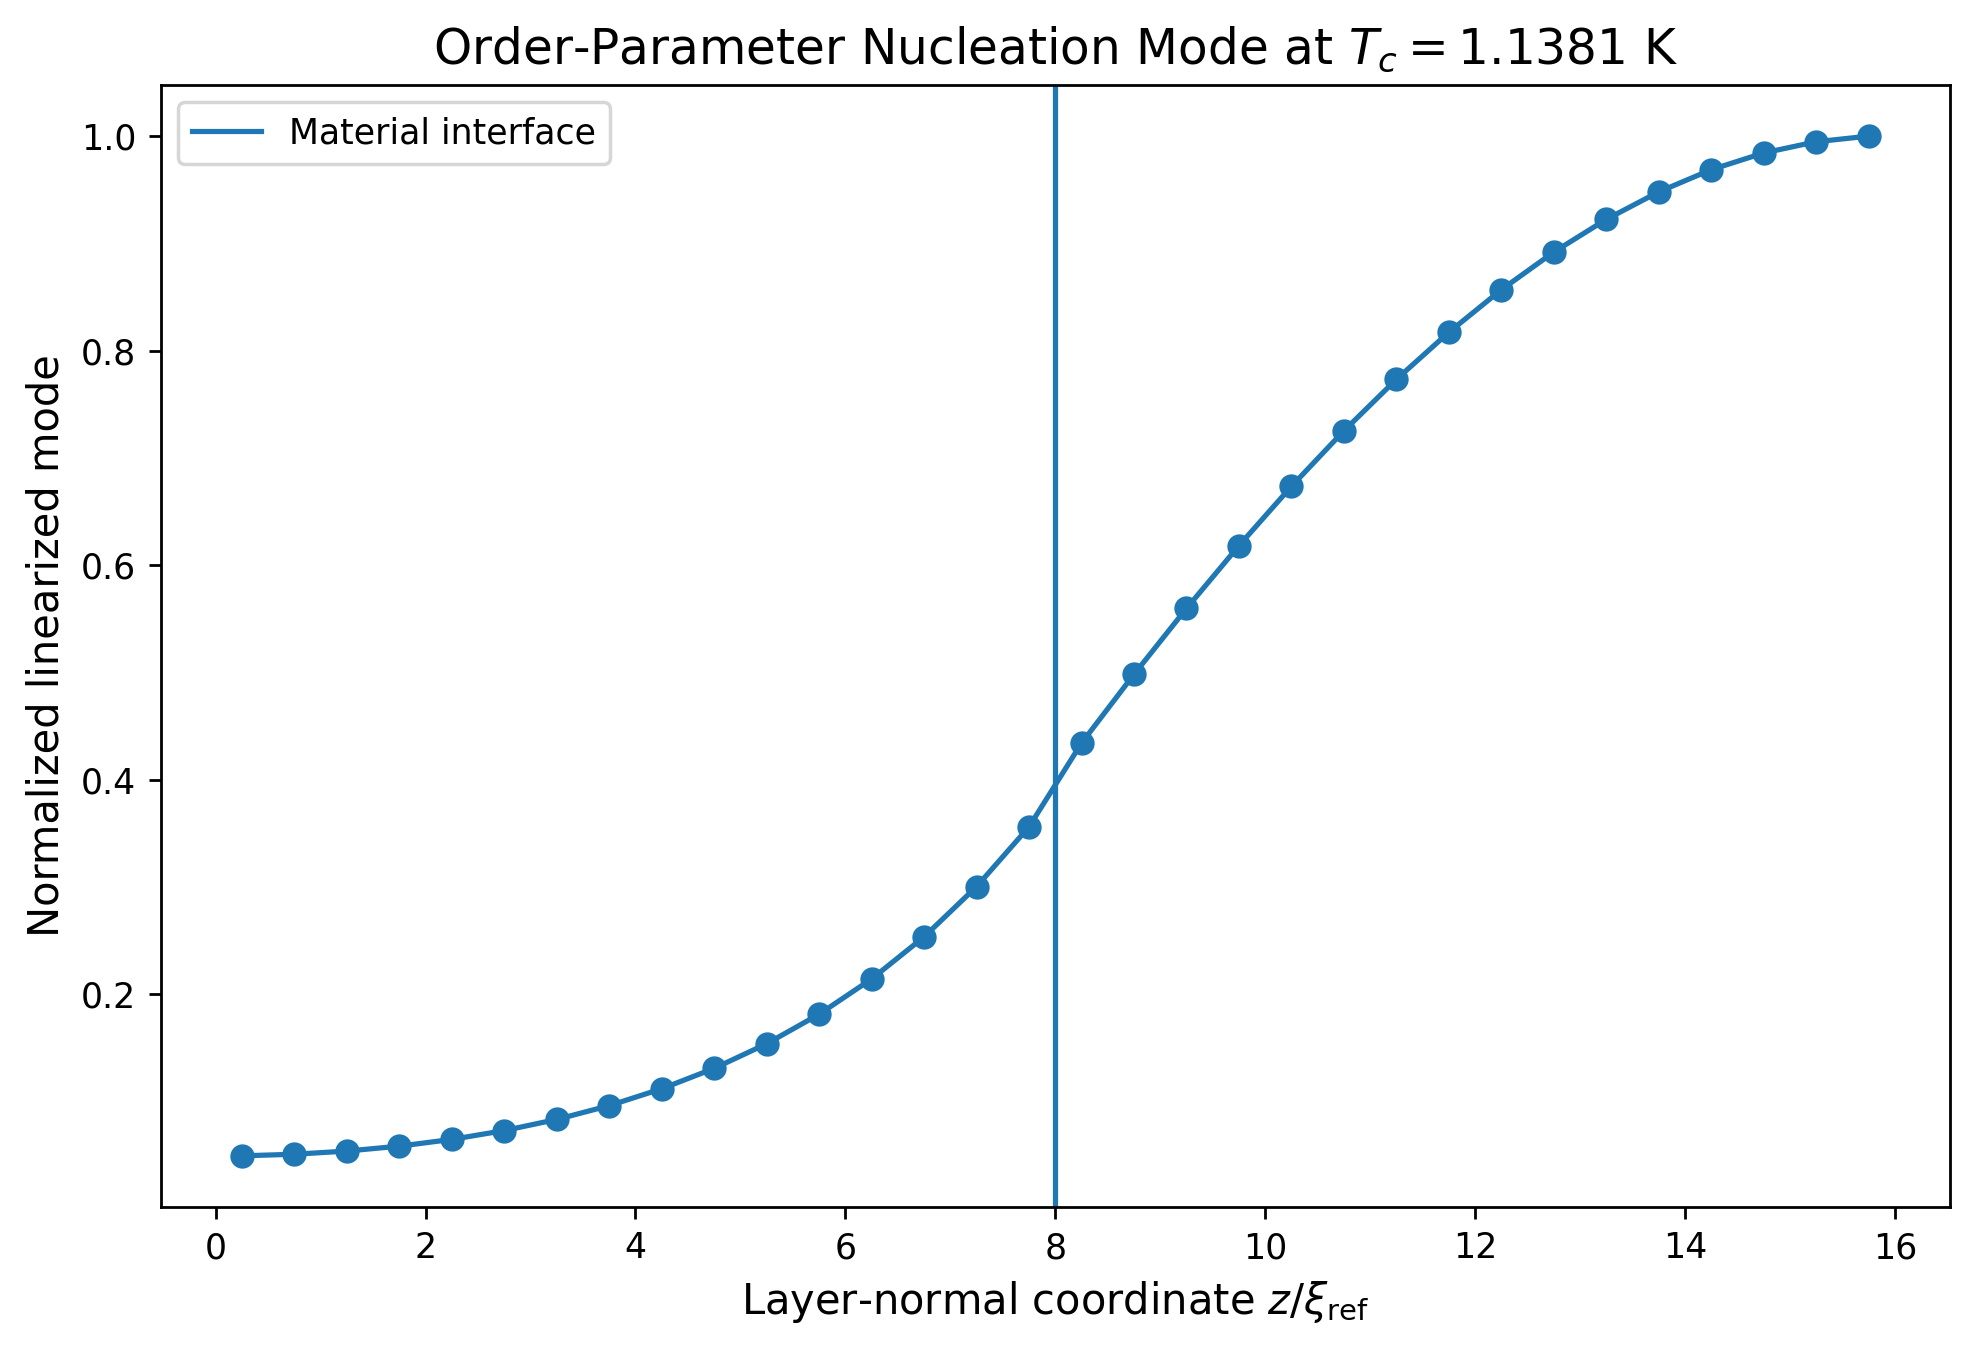

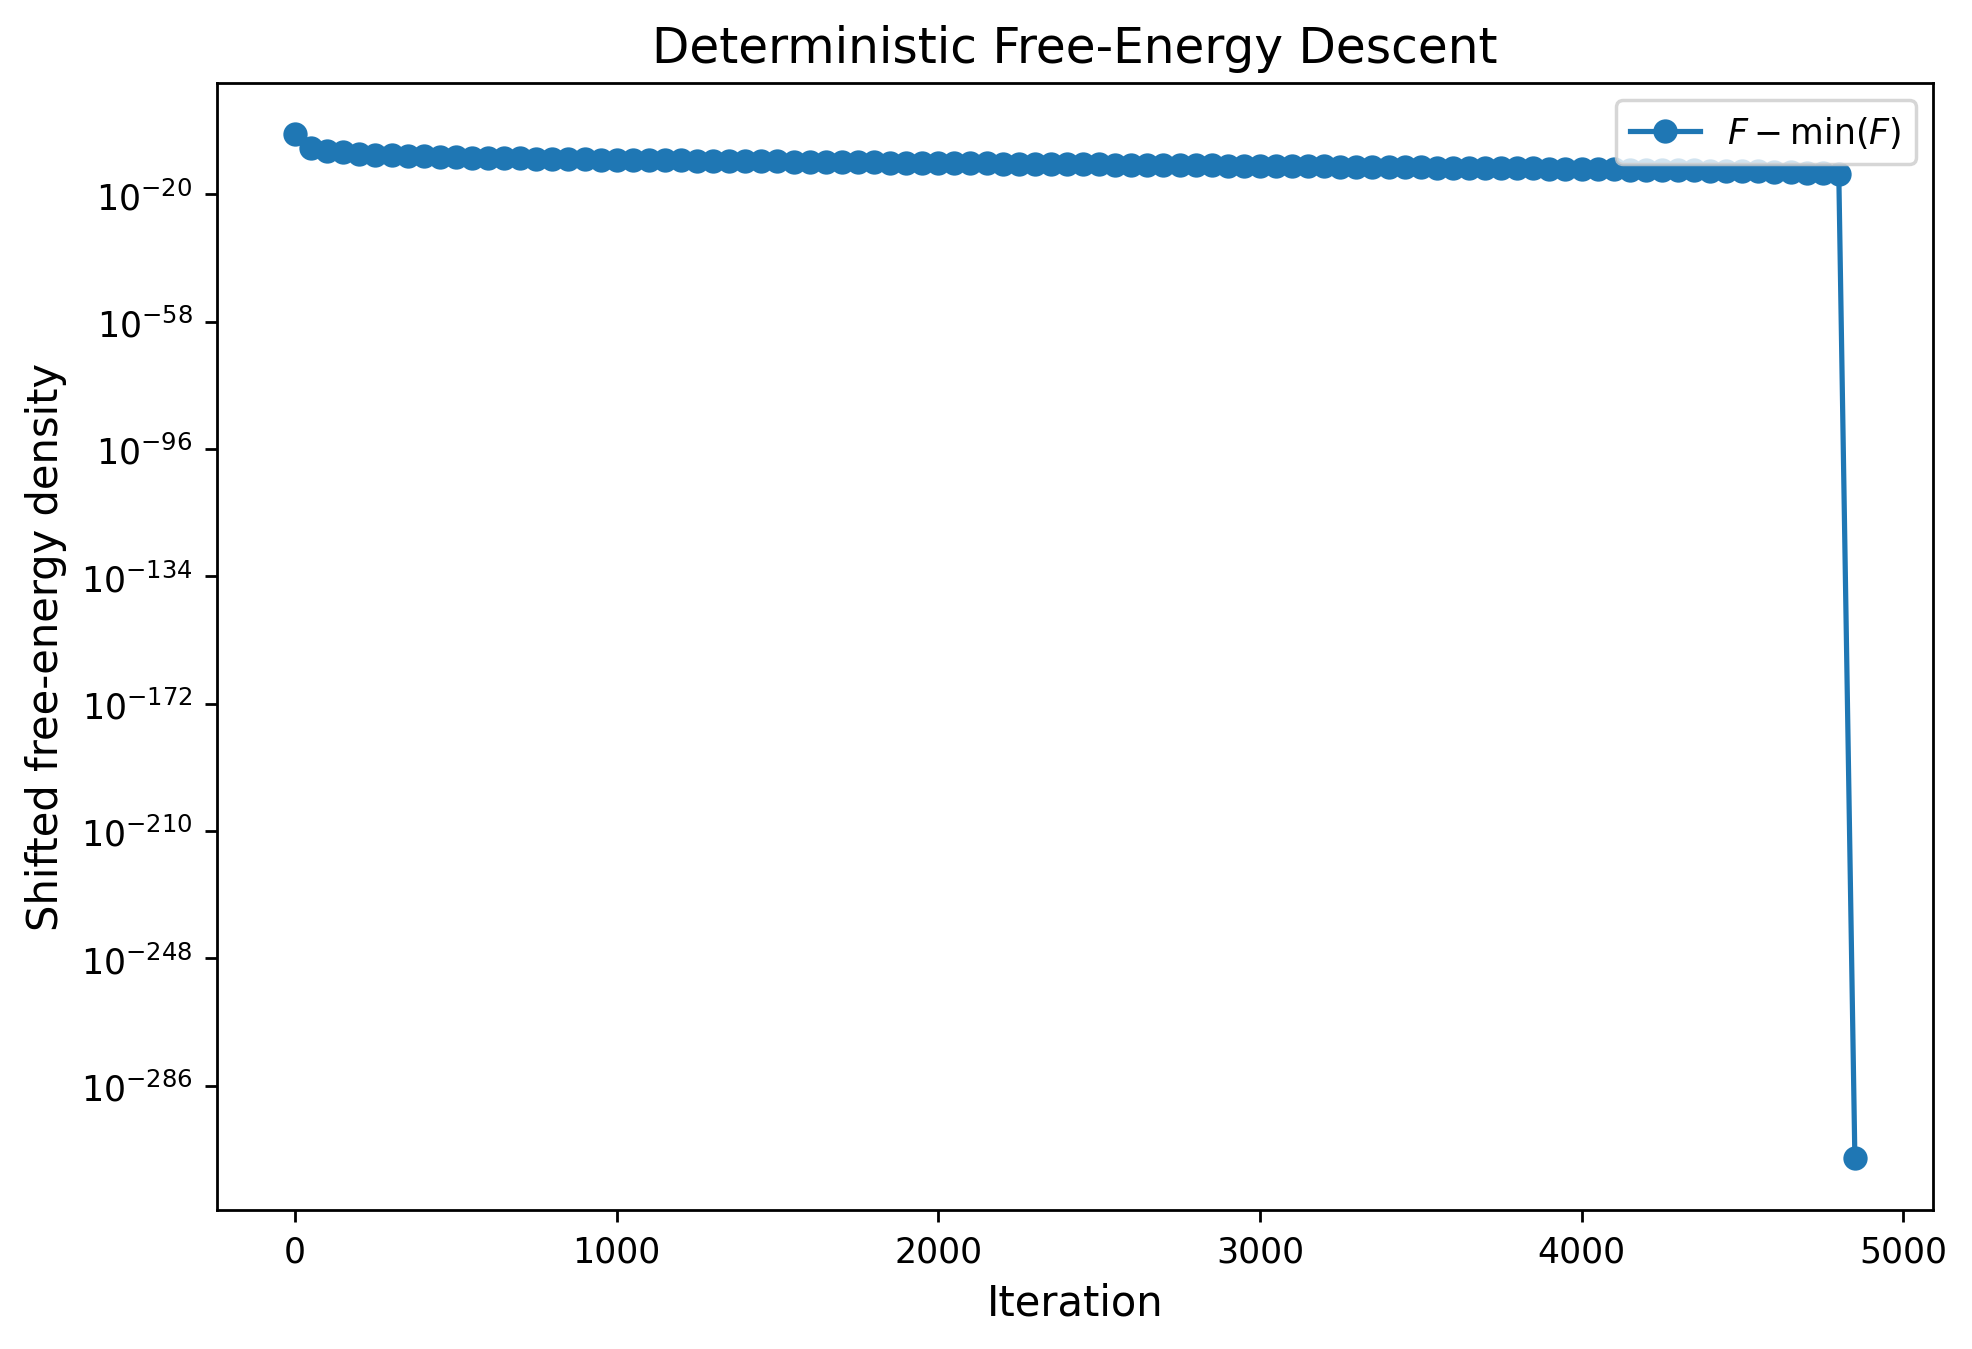

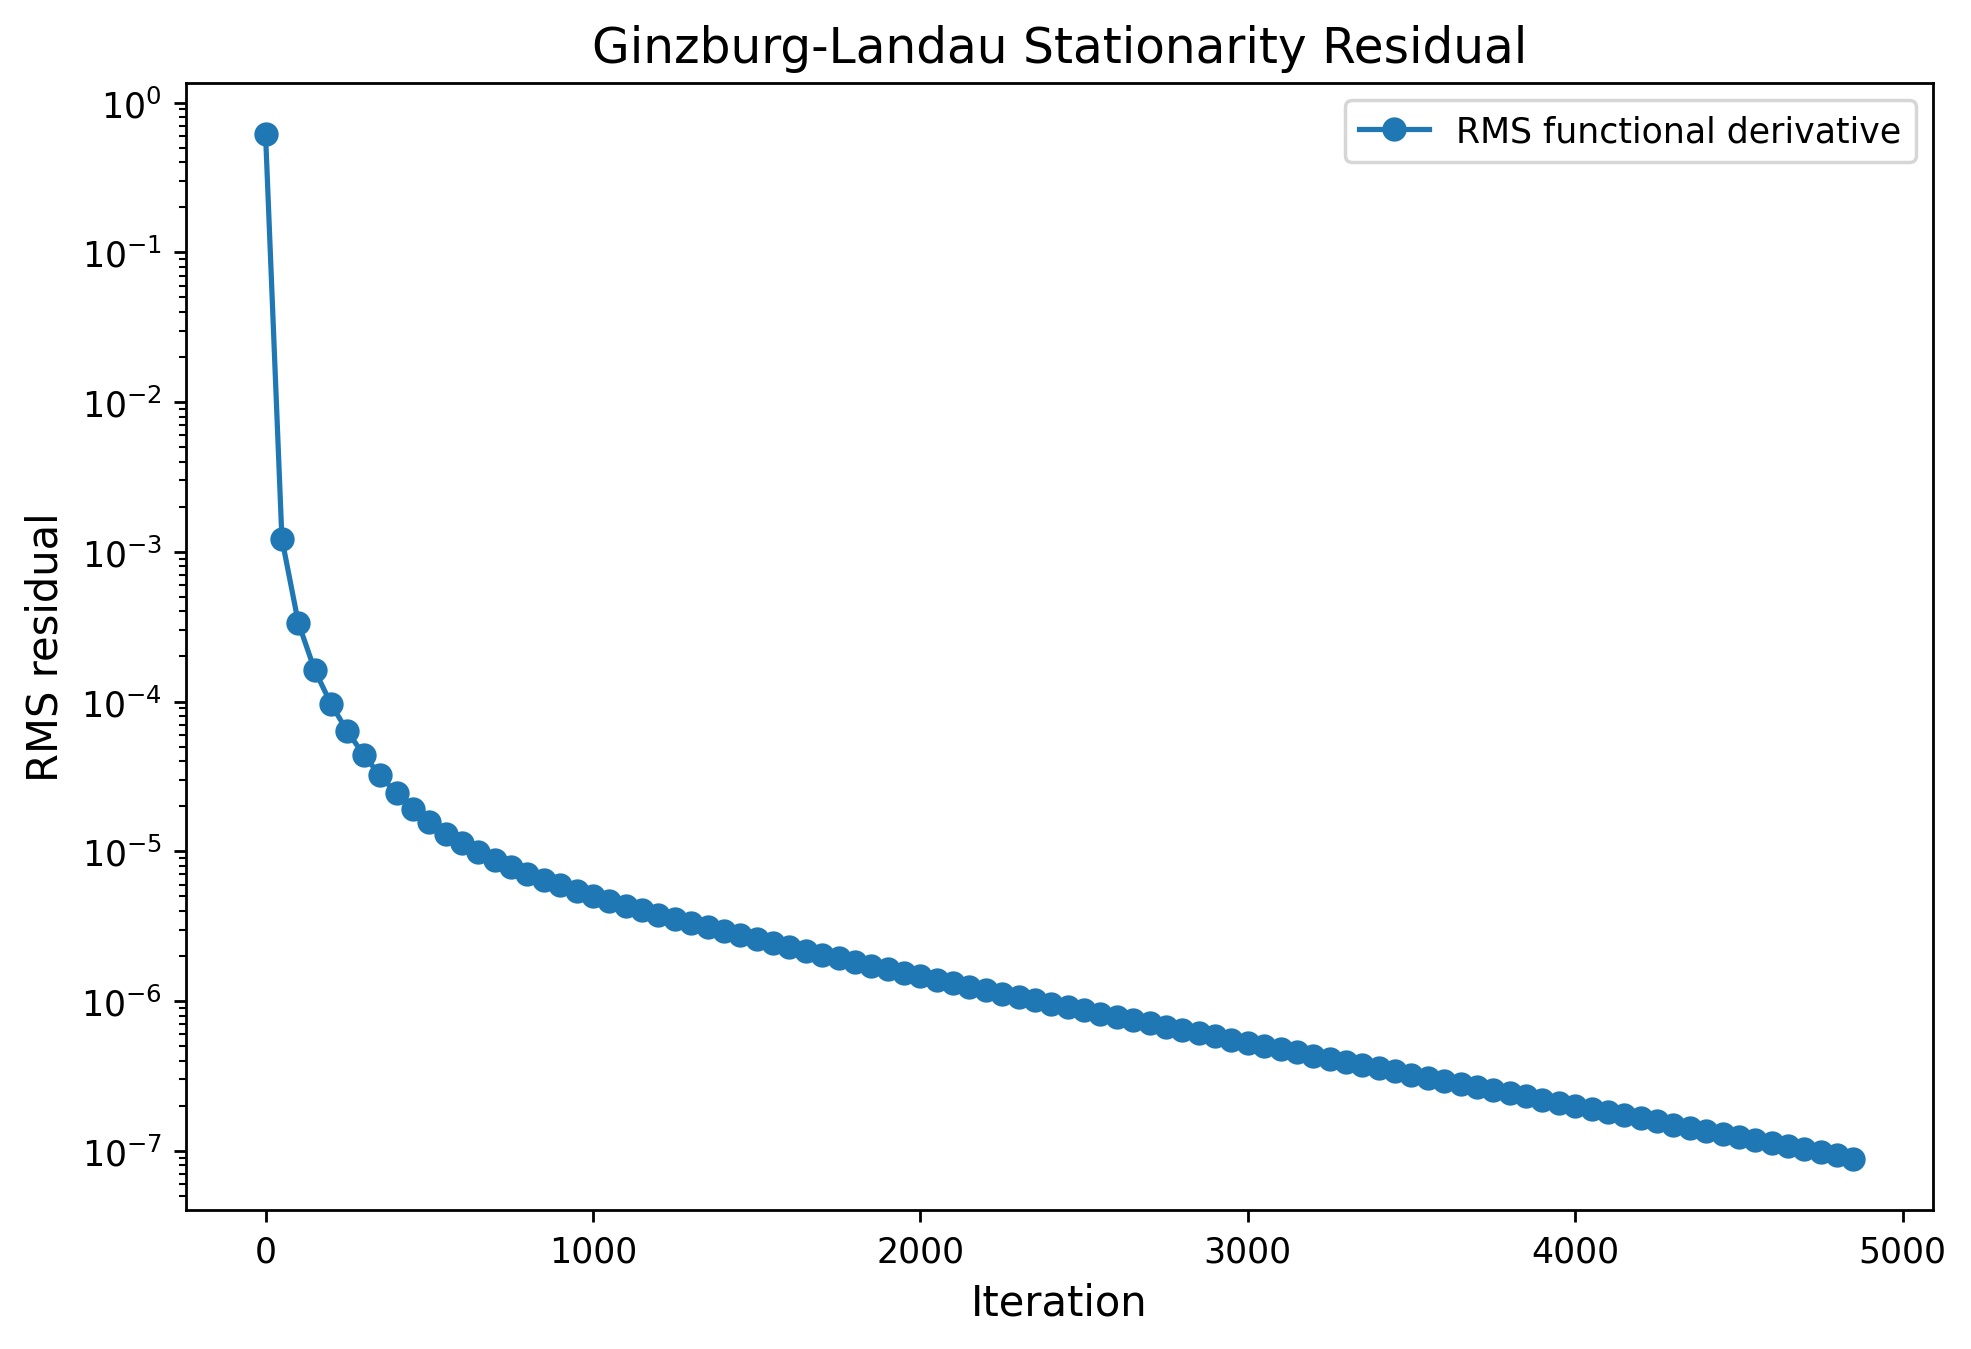

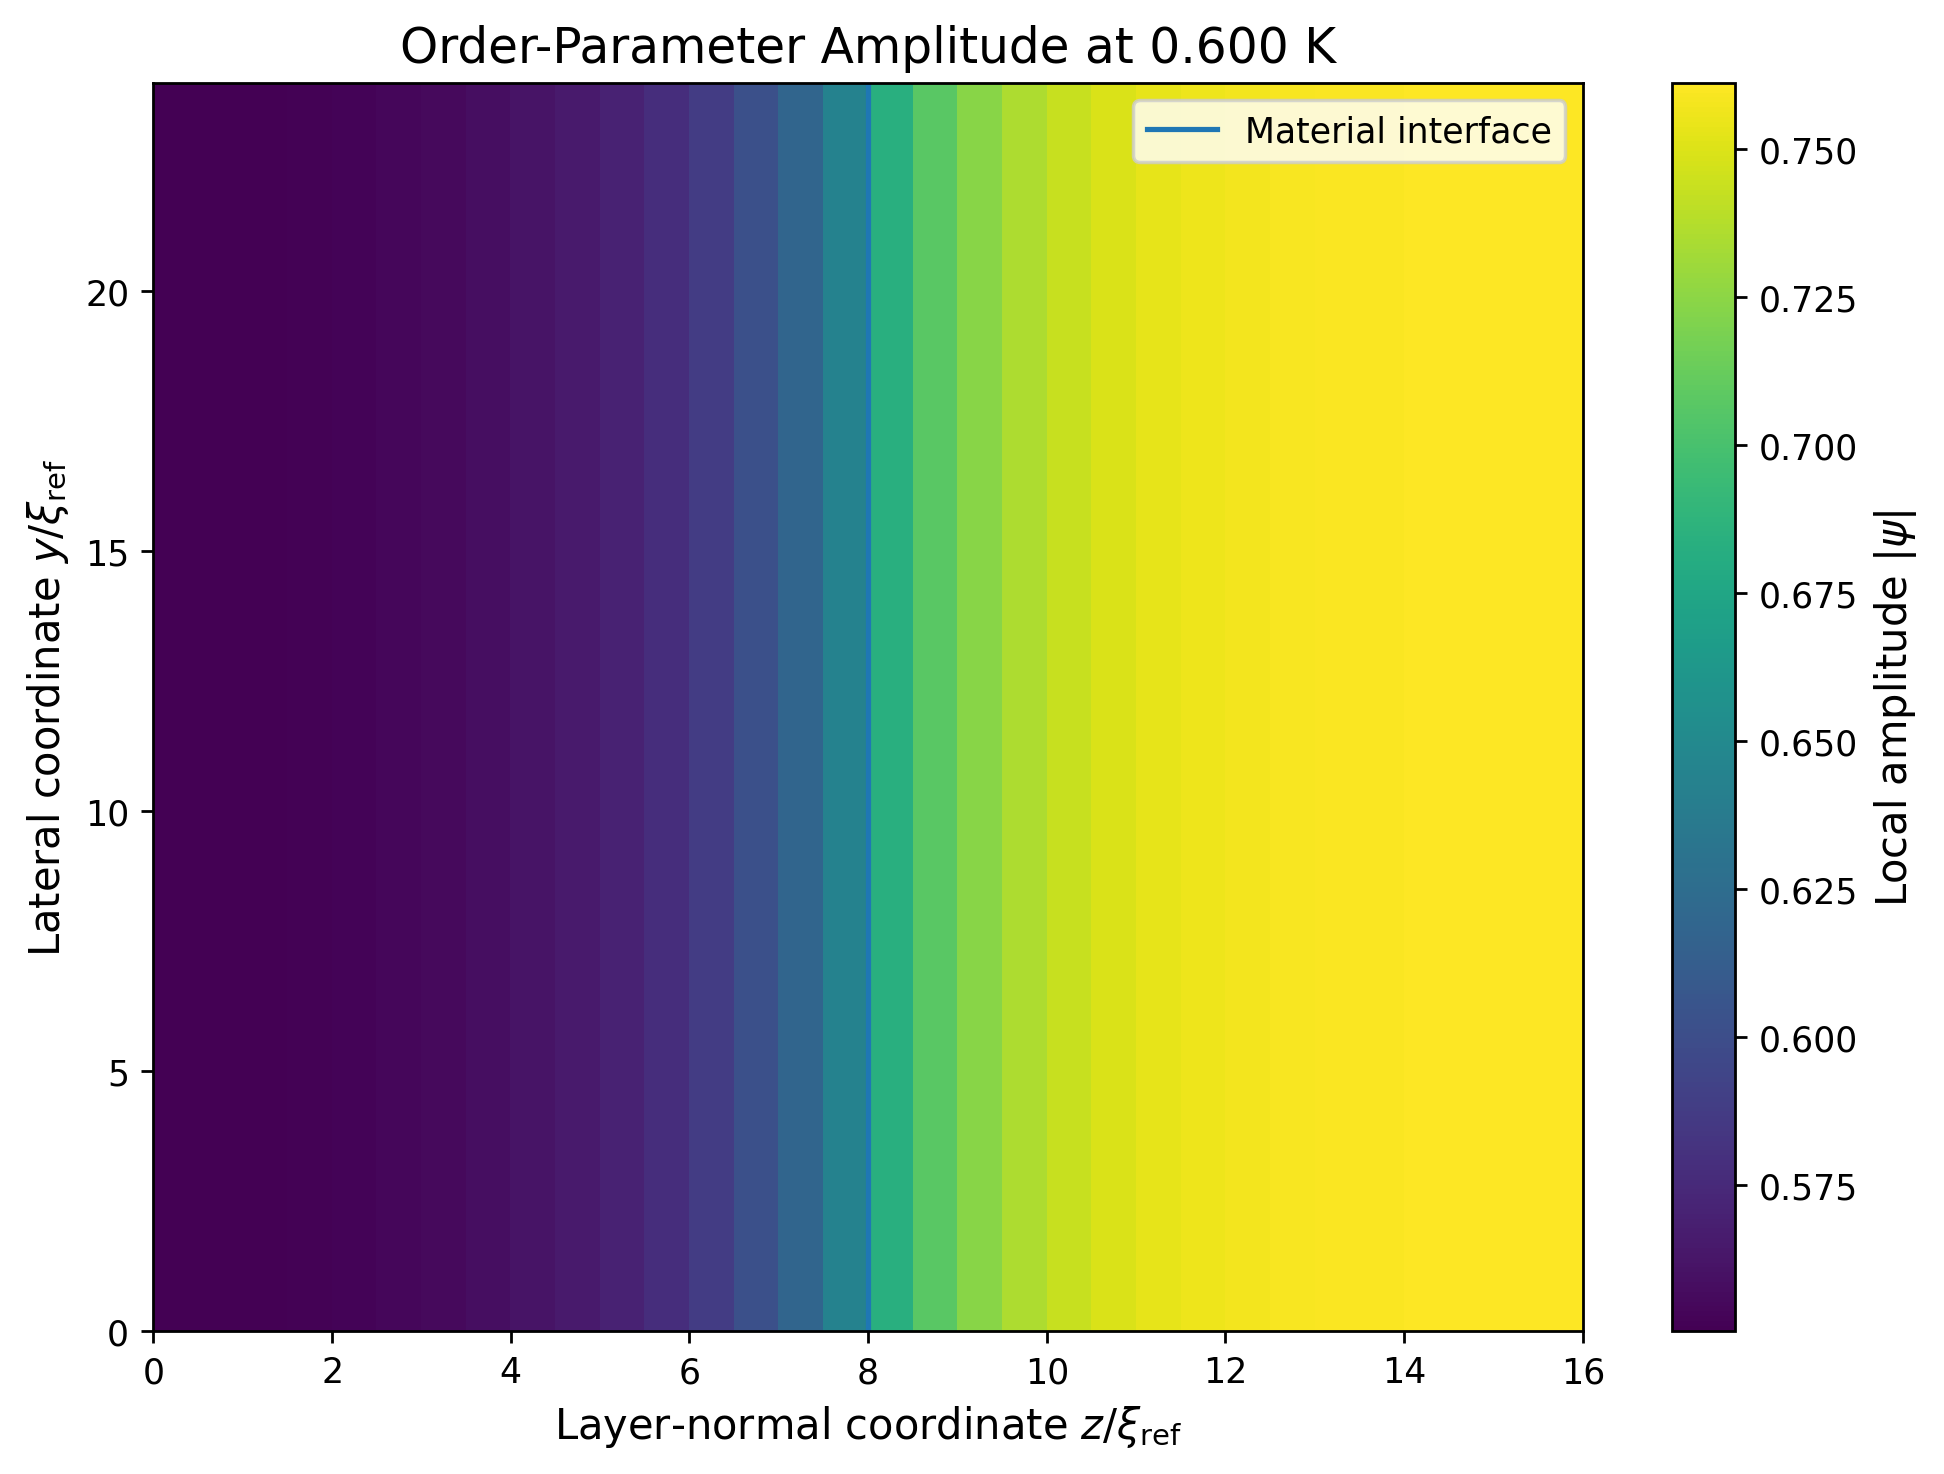

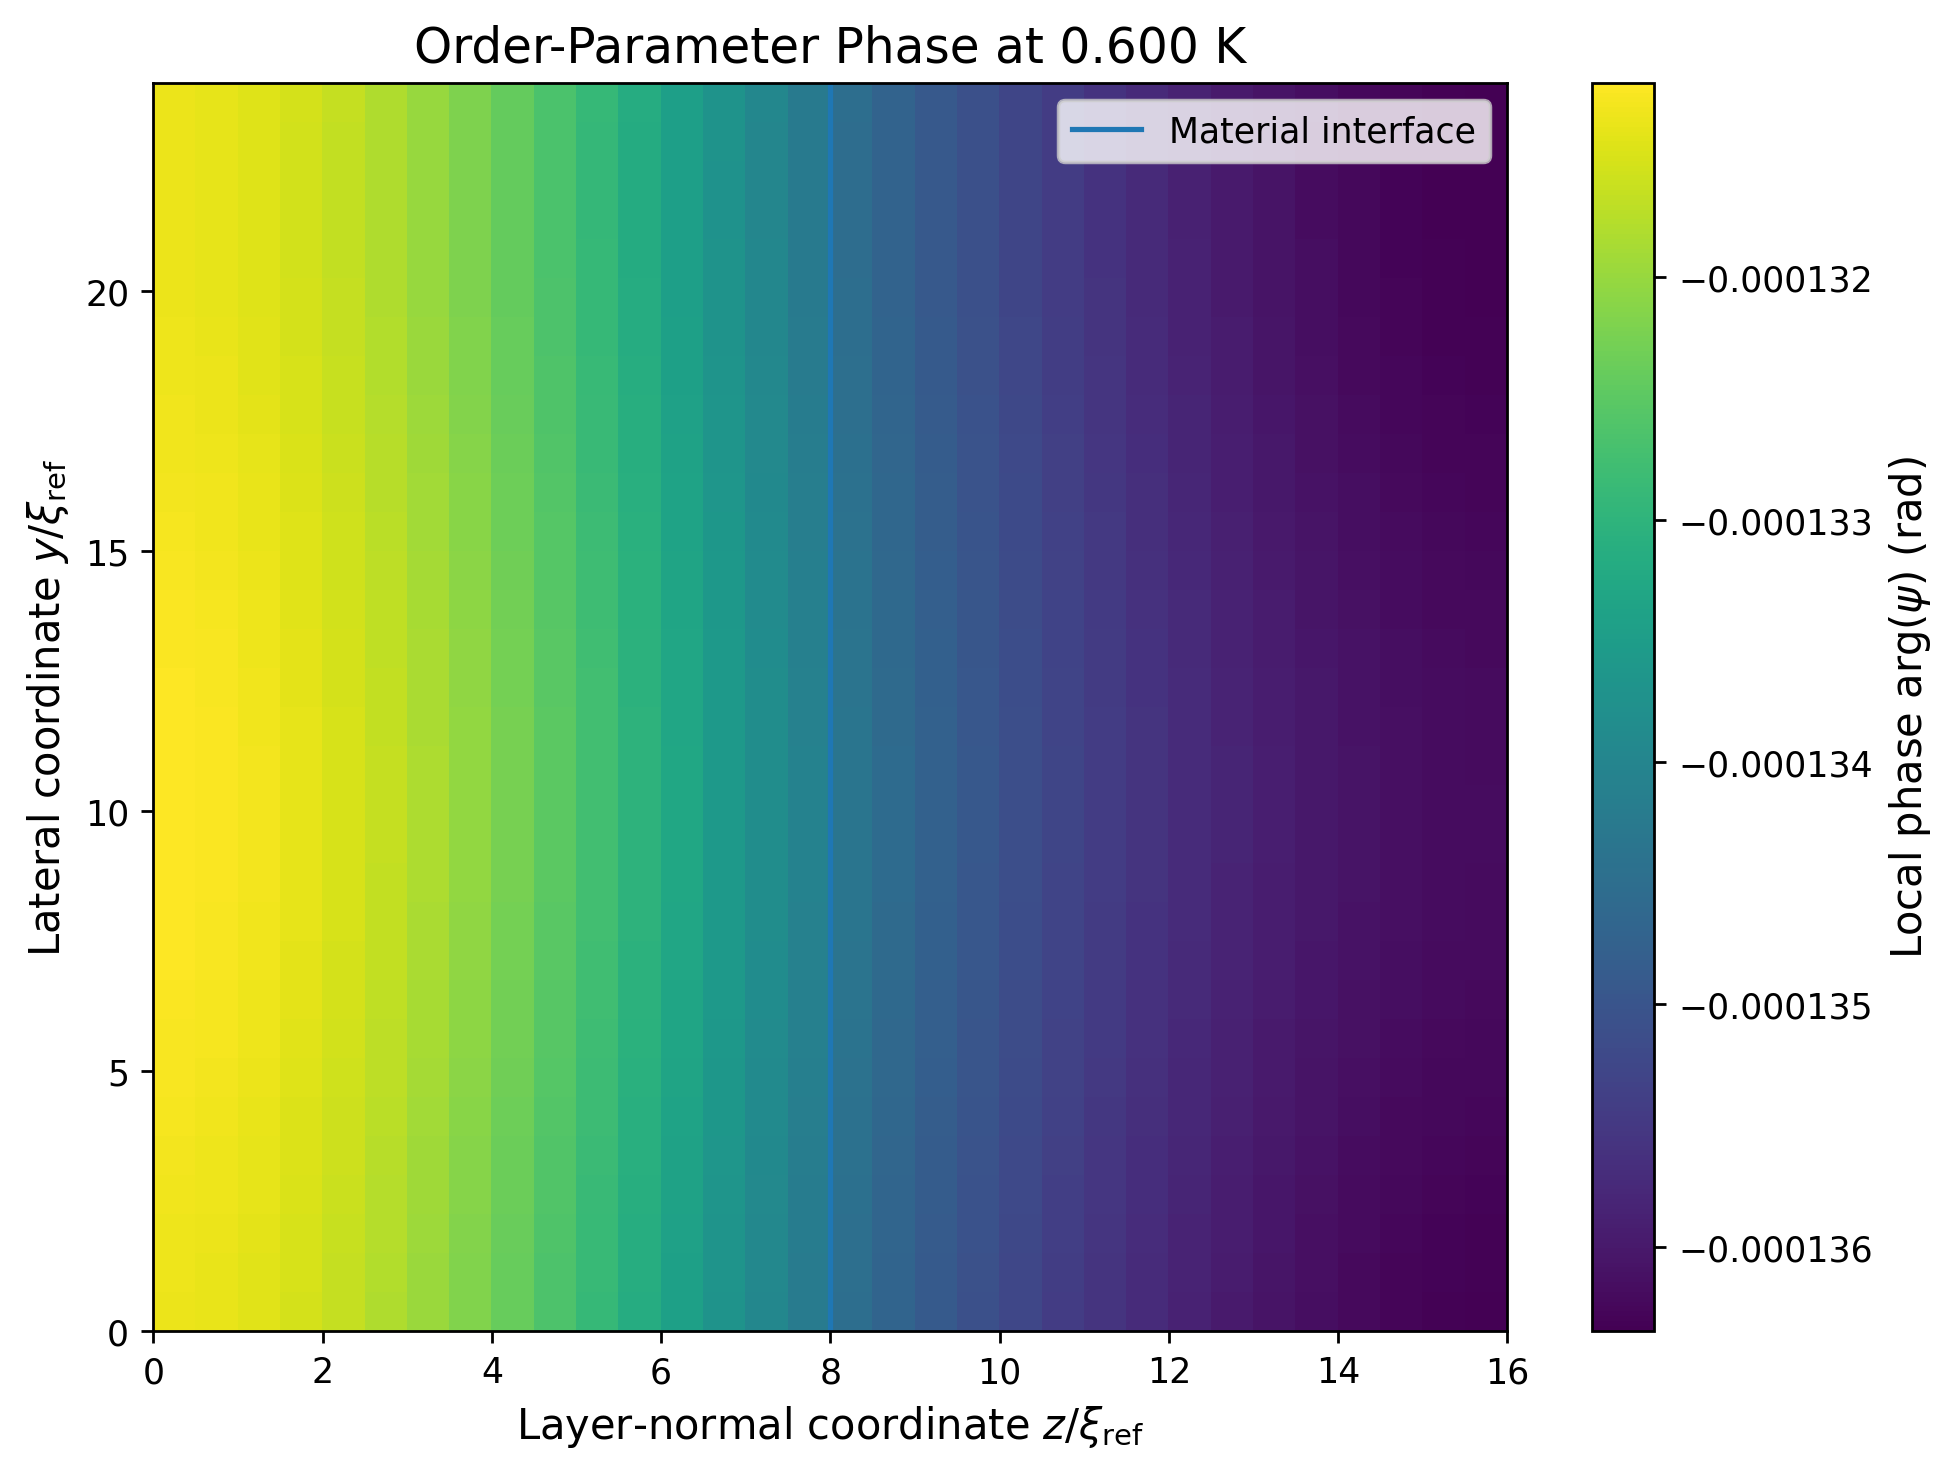

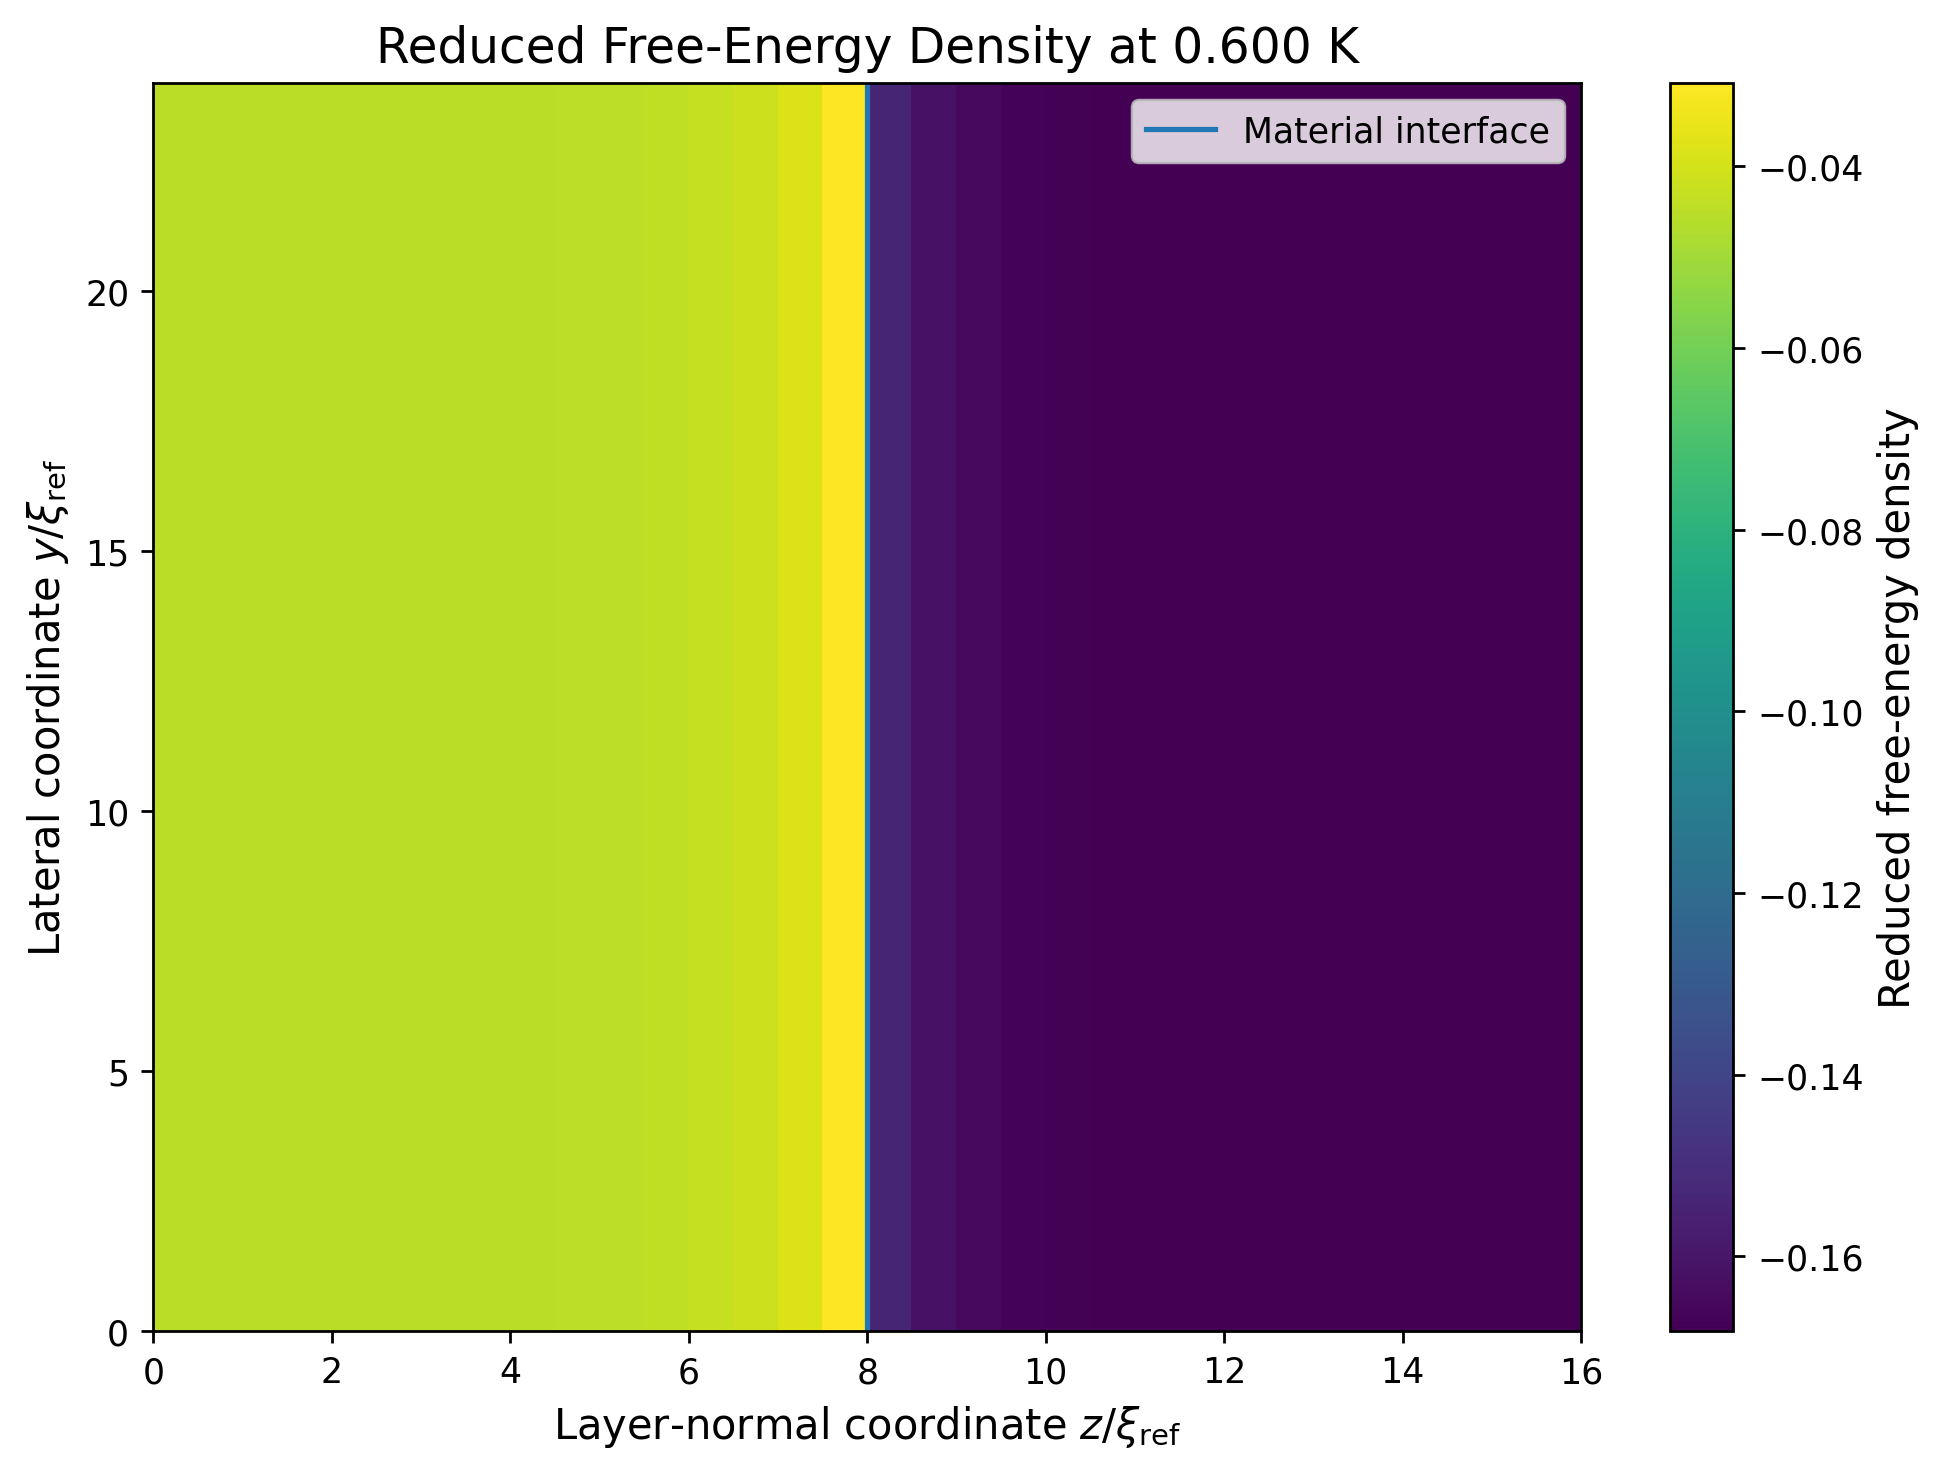

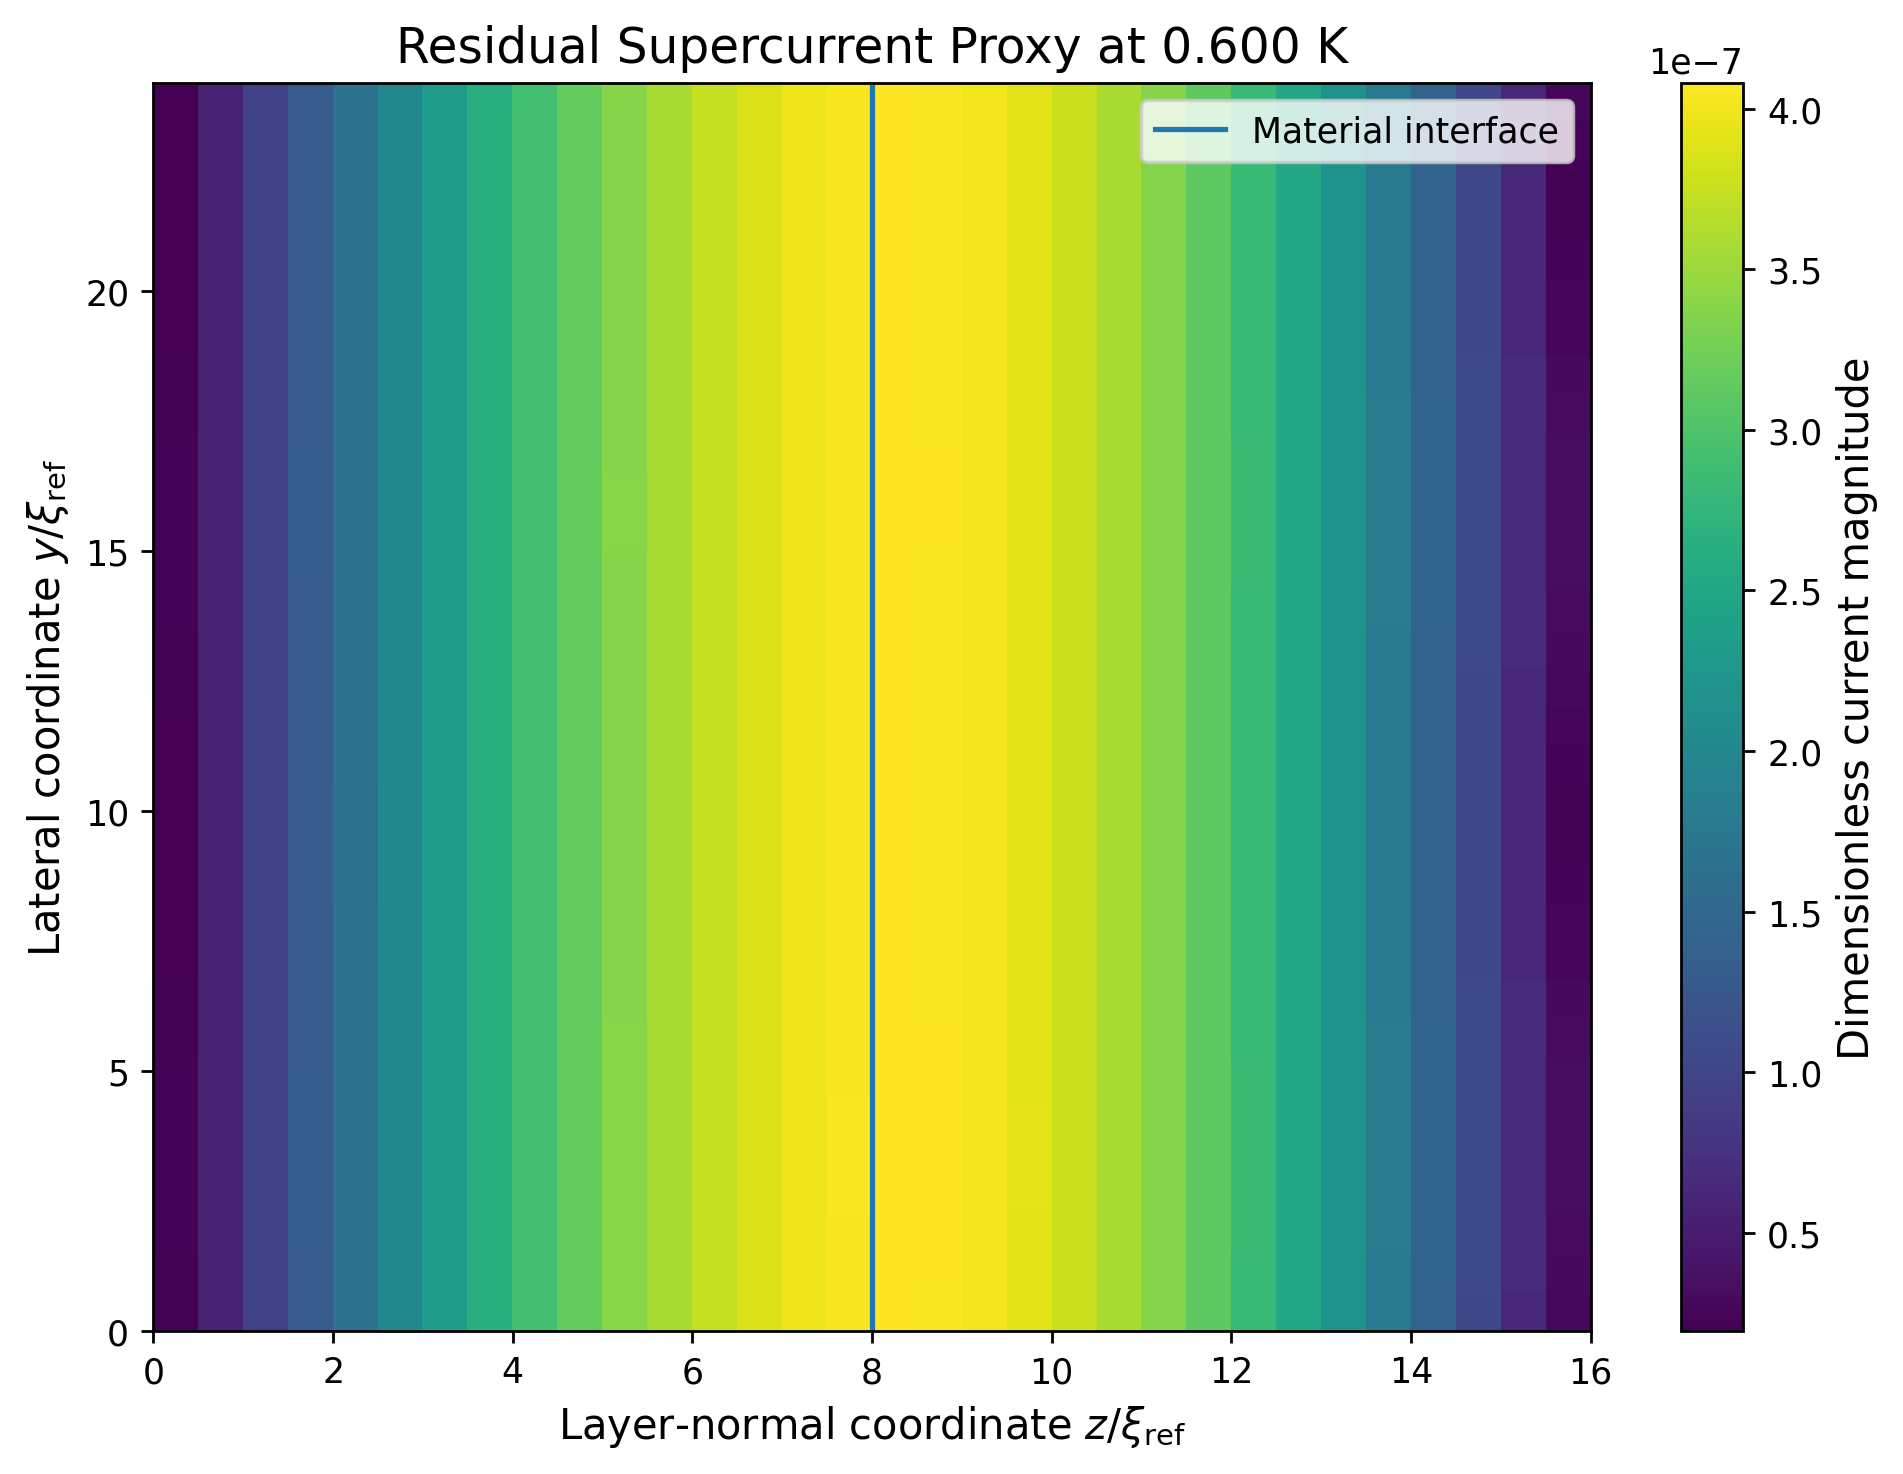

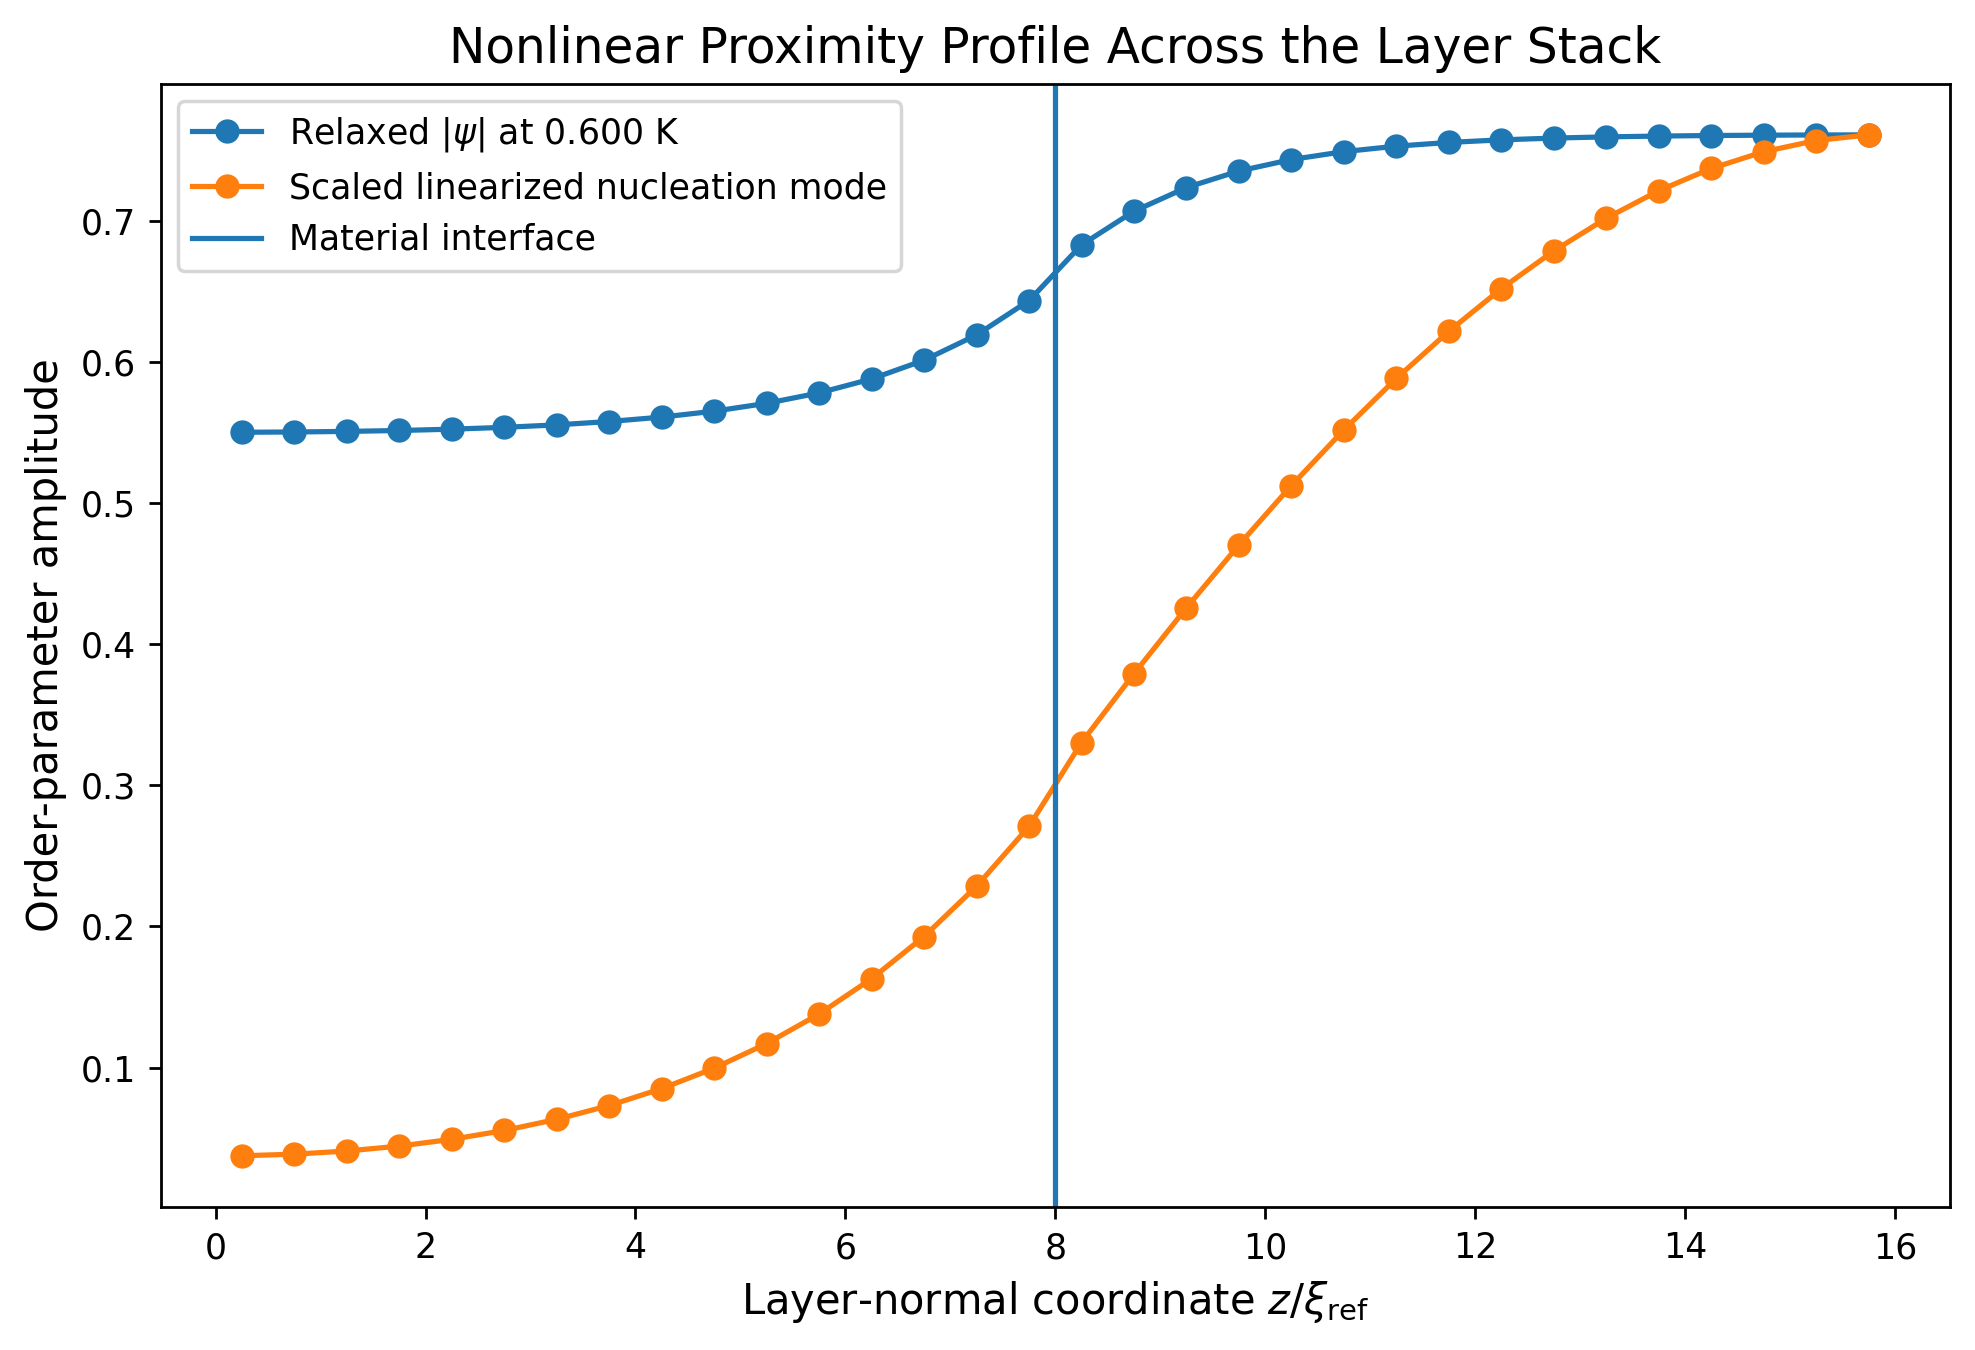

In [9]:
"""Model a layered superconducting transition with relaxational GL theory.

This module solves a zero-field, reduced-unit Ginzburg-Landau free-energy
relaxation for a stack of superconducting layers. It adds material-dependent
coefficients, finite-volume interface coupling, free-surface boundary
conditions, adaptive explicit stepping, convergence tests, temperature sweeps,
a linearized critical-temperature calculation, and spatial diagnostics.

The simulated evolution is pseudo-time gradient flow toward equilibrium. It
omits electromagnetic screening, applied vector potentials, transport bias,
microscopic quasiparticle kinetics, and self-consistent Usadel physics. The
results therefore support near-transition trend studies and numerical
experiments. Quantitative bilayer predictions require calibrated coefficients
or a microscopic proximity-effect model.
"""

import dataclasses
import math
from collections.abc import Sequence
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


@dataclasses.dataclass(frozen=True)
class LayerSpec:
    """Defines one layer in reduced Ginzburg-Landau units.

    Attributes:
        name: Display name for the material.
        cells: Number of cells along the layer-normal direction.
        critical_temperature_k: Intrinsic bulk critical temperature in kelvin.
        alpha0: Slope in alpha(T) = alpha0 * (T - Tc).
        beta: Quartic free-energy coefficient.
        stiffness: Gradient-energy coefficient in reduced spatial units.
    """

    name: str
    cells: int
    critical_temperature_k: float
    alpha0: float
    beta: float
    stiffness: float


@dataclasses.dataclass(frozen=True)
class SolverConfig:
    """Controls the gradient-flow solver.

    Attributes:
        max_iterations: Maximum number of explicit updates.
        max_time_step: Upper bound for the adaptive update step.
        min_time_step: Lower bound for the adaptive update step.
        stability_safety: Safety multiplier in the local stability estimate.
        adaptive_step_interval: Iterations between step-size estimates.
        check_interval: Iterations between convergence diagnostics.
        relative_update_tolerance: Relative field-update tolerance.
        gradient_rms_tolerance: RMS functional-derivative tolerance.
        convergence_patience: Consecutive successful checks required.
    """

    max_iterations: int
    max_time_step: float
    min_time_step: float
    stability_safety: float
    adaptive_step_interval: int
    check_interval: int
    relative_update_tolerance: float
    gradient_rms_tolerance: float
    convergence_patience: int


@dataclasses.dataclass(frozen=True)
class NewtonConfig:
    """Controls the one-dimensional damped Newton continuation.

    Attributes:
        max_iterations: Maximum Newton updates at each temperature.
        gradient_rms_tolerance: Stationarity-residual tolerance.
        relative_step_tolerance: Relative Newton-step tolerance.
        max_line_search_steps: Maximum backtracking trials per update.
        minimum_line_search_scale: Smallest accepted damping factor.
    """

    max_iterations: int
    gradient_rms_tolerance: float
    relative_step_tolerance: float
    max_line_search_steps: int
    minimum_line_search_scale: float


@dataclasses.dataclass
class RelaxationHistory:
    """Stores sampled convergence diagnostics."""

    iterations: list[int] = dataclasses.field(default_factory=list)
    free_energy_density: list[float] = dataclasses.field(default_factory=list)
    gradient_rms: list[float] = dataclasses.field(default_factory=list)
    relative_update: list[float] = dataclasses.field(default_factory=list)
    time_step: list[float] = dataclasses.field(default_factory=list)
    converged: bool = False
    iterations_completed: int = 0
    energy_increase_count: int = 0


@dataclasses.dataclass(frozen=True)
class Observables:
    """Contains scalar diagnostics for one relaxed state."""

    mean_amplitude: float
    condensate_density: float
    phase_coherence: float
    interface_phase_locking: float
    interface_amplitude_mismatch: float
    supercurrent_rms: float
    free_energy_density: float
    layer_densities: dict[str, float]


@dataclasses.dataclass(frozen=True)
class TemperatureSweepResult:
    """Contains equilibrium data sampled over temperature."""

    temperatures_k: np.ndarray
    condensate_density: np.ndarray
    mean_amplitude: np.ndarray
    free_energy_density: np.ndarray
    interface_amplitude_mismatch: np.ndarray
    iterations: np.ndarray
    converged: np.ndarray
    layer_densities: dict[str, np.ndarray]
    profiles: np.ndarray


@dataclasses.dataclass(frozen=True)
class LinearizedTransition:
    """Contains the critical point of the linearized GL operator."""

    temperature_k: float
    mode_profile: np.ndarray
    residual_eigenvalue: float


# =============================================================================
# Global Control Knobs
# =============================================================================
PREFER_GPU = True
RANDOM_SEED = 20260722
USE_FLOAT64 = True

LAYER_SPECS: tuple[LayerSpec, ...] = (
    LayerSpec(
        name="Mo",
        cells=16,
        critical_temperature_k=0.90,
        alpha0=1.00,
        beta=1.00,
        stiffness=2.00,
    ),
    LayerSpec(
        name="Al",
        cells=16,
        critical_temperature_k=1.18,
        alpha0=1.00,
        beta=1.00,
        stiffness=2.00,
    ),
)

# One value per material interface. A value of 1 gives a transparent interface.
# Smaller positive values suppress order-parameter transfer across that face.
INTERFACE_TRANSPARENCIES: tuple[float, ...] = (0.85,)

LATERAL_GRID_SHAPE = (32, 32)
GRID_SPACING_XI = (0.75, 0.75, 0.50)
TARGET_TEMPERATURE_K = 0.60

TEMPERATURE_MIN_K = 0.35
TEMPERATURE_MAX_K = 1.32
TEMPERATURE_SAMPLE_COUNT = 29

INITIAL_FIELD_FLOOR = 1.0e-6
INITIAL_NOISE_FRACTION = 2.0e-2
PHASE_MASK_FRACTION = 1.0e-3

SWEEP_NEWTON_CONFIG = NewtonConfig(
    max_iterations=80,
    gradient_rms_tolerance=1.0e-11,
    relative_step_tolerance=1.0e-10,
    max_line_search_steps=32,
    minimum_line_search_scale=2.0 ** -32,
)

TARGET_SOLVER_CONFIG = SolverConfig(
    max_iterations=5000,
    max_time_step=0.020,
    min_time_step=1.0e-6,
    stability_safety=0.75,
    adaptive_step_interval=20,
    check_interval=50,
    relative_update_tolerance=2.0e-9,
    gradient_rms_tolerance=1.0e-7,
    convergence_patience=3,
)

PLOT_TEMPERATURE_RESPONSE = True
PLOT_INTERFACE_RESPONSE = True
PLOT_SWEEP_CONVERGENCE = True
PLOT_LINEARIZED_MODE = True
PLOT_TARGET_CONVERGENCE = True
PLOT_AMPLITUDE_MAP = True
PLOT_PHASE_MAP = True
PLOT_FREE_ENERGY_MAP = True
PLOT_SUPERCURRENT_MAP = True
PLOT_DEPTH_PROFILE = True

mpl.rcParams["figure.dpi"] = 250
mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["font.weight"] = "normal"
# =============================================================================


def _select_backend(prefer_gpu: bool) -> tuple[Any, str]:
    """Selects CuPy when a CUDA device is available.

    Args:
        prefer_gpu: Enables the CUDA backend probe.

    Returns:
        A numerical array module and a human-readable device description.
    """

    if prefer_gpu:
        try:
            import cupy as cp  # pylint: disable=import-outside-toplevel

            device_count = int(cp.cuda.runtime.getDeviceCount())
            if device_count < 1:
                raise RuntimeError("CUDA reported zero devices.")
            device_id = int(cp.cuda.runtime.getDevice())
            properties = cp.cuda.runtime.getDeviceProperties(device_id)
            raw_name = properties.get("name", b"CUDA GPU")
            device_name = (
                raw_name.decode("utf-8")
                if isinstance(raw_name, bytes)
                else str(raw_name)
            )
            cp.zeros(1, dtype=cp.float32)
            return cp, f"GPU {device_id}: {device_name}"
        except (ImportError, OSError, RuntimeError) as error:
            return np, f"CPU NumPy fallback after CUDA probe: {error}"

    return np, "CPU NumPy"


def _to_numpy(array: Any) -> np.ndarray:
    """Transfers an array to host memory.

    Args:
        array: NumPy-compatible or CuPy-compatible array.

    Returns:
        A NumPy array.
    """

    if hasattr(array, "get"):
        return np.asarray(array.get())
    return np.asarray(array)


def _to_float(value: Any) -> float:
    """Converts a backend scalar to a Python float."""

    if hasattr(value, "item"):
        return float(value.item())
    return float(value)


def _validate_inputs(
    layers: Sequence[LayerSpec],
    interface_transparencies: Sequence[float],
    spacing: tuple[float, float, float],
) -> None:
    """Validates material and mesh controls.

    Args:
        layers: Ordered layer descriptions.
        interface_transparencies: Coupling factors between adjacent layers.
        spacing: Grid spacing in reduced coherence-length units.

    Raises:
        ValueError: A control value is outside its valid range.
    """

    if len(layers) < 1:
        raise ValueError("At least one layer is required.")
    if len(interface_transparencies) != max(0, len(layers) - 1):
        raise ValueError(
            "INTERFACE_TRANSPARENCIES needs one value per interface."
        )
    if any(value <= 0.0 for value in spacing):
        raise ValueError("Every grid spacing needs a positive value.")
    for layer in layers:
        if layer.cells < 1:
            raise ValueError(f"Layer {layer.name} needs at least one cell.")
        if layer.alpha0 <= 0.0:
            raise ValueError(f"Layer {layer.name} needs alpha0 above zero.")
        if layer.beta <= 0.0:
            raise ValueError(f"Layer {layer.name} needs beta above zero.")
        if layer.stiffness <= 0.0:
            raise ValueError(
                f"Layer {layer.name} needs stiffness above zero."
            )
    for transparency in interface_transparencies:
        if transparency <= 0.0 or transparency > 1.0:
            raise ValueError(
                "Each interface transparency needs a value in (0, 1]."
            )


def _build_host_material_arrays(
    layers: Sequence[LayerSpec],
    interface_transparencies: Sequence[float],
) -> dict[str, np.ndarray]:
    """Builds one-dimensional material arrays on the host.

    Args:
        layers: Ordered layer descriptions.
        interface_transparencies: Coupling factors between adjacent layers.

    Returns:
        Material arrays indexed along the layer-normal direction.
    """

    layer_ids: list[int] = []
    critical_temperatures: list[float] = []
    alpha0_values: list[float] = []
    beta_values: list[float] = []
    stiffness_values: list[float] = []

    for layer_id, layer in enumerate(layers):
        layer_ids.extend([layer_id] * layer.cells)
        critical_temperatures.extend(
            [layer.critical_temperature_k] * layer.cells
        )
        alpha0_values.extend([layer.alpha0] * layer.cells)
        beta_values.extend([layer.beta] * layer.cells)
        stiffness_values.extend([layer.stiffness] * layer.cells)

    layer_id_array = np.asarray(layer_ids, dtype=np.int32)
    stiffness_array = np.asarray(stiffness_values, dtype=np.float64)
    left_stiffness = stiffness_array[:-1]
    right_stiffness = stiffness_array[1:]
    face_stiffness = (
        2.0
        * left_stiffness
        * right_stiffness
        / np.maximum(left_stiffness + right_stiffness, 1.0e-30)
    )

    interface_faces = np.flatnonzero(
        layer_id_array[:-1] != layer_id_array[1:]
    )
    for interface_number, face_index in enumerate(interface_faces):
        face_stiffness[face_index] *= interface_transparencies[
            interface_number
        ]

    return {
        "layer_id": layer_id_array,
        "critical_temperature": np.asarray(
            critical_temperatures, dtype=np.float64
        ),
        "alpha0": np.asarray(alpha0_values, dtype=np.float64),
        "beta": np.asarray(beta_values, dtype=np.float64),
        "stiffness": stiffness_array,
        "face_stiffness": face_stiffness,
        "interface_faces": interface_faces,
    }


class LayeredGinzburgLandauSimulation:
    """Relaxes a complex order parameter in a layered zero-field geometry.

    The lateral boundaries are periodic. The two outer layer-normal surfaces
    use zero-normal-gradient boundary conditions. Material interfaces use a
    harmonic-mean face stiffness multiplied by a transparency control.

    Attributes:
        shape: Three-dimensional lattice shape.
        layers: Ordered material descriptions.
        spacing: Reduced grid spacing along x, y, and z.
        xp: Active numerical backend.
        psi: Complex superconducting order-parameter field.
    """

    def __init__(
        self,
        lateral_shape: tuple[int, int],
        layers: Sequence[LayerSpec],
        spacing: tuple[float, float, float],
        interface_transparencies: Sequence[float],
        xp: Any,
        seed: int,
        use_float64: bool,
    ) -> None:
        """Initializes geometry, material coefficients, and random generator.

        Args:
            lateral_shape: Cell counts along x and y.
            layers: Ordered layer descriptions.
            spacing: Grid spacing in reduced coherence-length units.
            interface_transparencies: Coupling factors between layers.
            xp: NumPy-compatible numerical backend.
            seed: Reproducible random seed.
            use_float64: Selects float64 and complex128 storage.
        """

        _validate_inputs(layers, interface_transparencies, spacing)
        if lateral_shape[0] < 1 or lateral_shape[1] < 1:
            raise ValueError("Lateral dimensions need at least one cell.")

        self.layers = tuple(layers)
        self.spacing = spacing
        self.xp = xp
        self.real_dtype = xp.float64 if use_float64 else xp.float32
        self.complex_dtype = (
            xp.complex128 if use_float64 else xp.complex64
        )
        self.host_materials = _build_host_material_arrays(
            self.layers, interface_transparencies
        )
        self.nz = int(self.host_materials["layer_id"].size)
        self.shape = (lateral_shape[0], lateral_shape[1], self.nz)
        self.rng = xp.random.default_rng(seed)

        self.layer_id_z = xp.asarray(
            self.host_materials["layer_id"], dtype=xp.int32
        )
        self.critical_temperature_z = xp.asarray(
            self.host_materials["critical_temperature"],
            dtype=self.real_dtype,
        ).reshape(1, 1, self.nz)
        self.alpha0_z = xp.asarray(
            self.host_materials["alpha0"], dtype=self.real_dtype
        ).reshape(1, 1, self.nz)
        self.beta_z = xp.asarray(
            self.host_materials["beta"], dtype=self.real_dtype
        ).reshape(1, 1, self.nz)
        self.stiffness_z = xp.asarray(
            self.host_materials["stiffness"], dtype=self.real_dtype
        ).reshape(1, 1, self.nz)
        self.face_stiffness_z = xp.asarray(
            self.host_materials["face_stiffness"],
            dtype=self.real_dtype,
        ).reshape(1, 1, self.nz - 1)

        self.max_beta = float(np.max(self.host_materials["beta"]))
        self.max_stiffness = float(
            np.max(self.host_materials["stiffness"])
        )
        self.psi = xp.zeros(self.shape, dtype=self.complex_dtype)

    def alpha(self, temperature_k: float) -> Any:
        """Calculates alpha(T) across the stack.

        Args:
            temperature_k: Simulation temperature in kelvin.

        Returns:
            A broadcastable alpha array with shape (1, 1, nz).
        """

        return self.alpha0_z * (
            temperature_k - self.critical_temperature_z
        )

    def initialize_bulk_guess(
        self,
        temperature_k: float,
        field_floor: float,
        noise_fraction: float,
    ) -> None:
        """Initializes a coherent field from local bulk GL amplitudes.

        Args:
            temperature_k: Temperature in kelvin.
            field_floor: Positive seed amplitude retained above transition.
            noise_fraction: Fractional amplitude and phase perturbation.
        """

        alpha_z = self.alpha(temperature_k)
        bulk_density = self.xp.maximum(-alpha_z / self.beta_z, 0.0)
        profile = self.xp.sqrt(bulk_density)
        profile = self.xp.maximum(profile, field_floor)
        profile = self.xp.broadcast_to(profile, self.shape)

        amplitude_noise = noise_fraction * self.rng.standard_normal(
            self.shape
        ).astype(self.real_dtype)
        phase_noise = noise_fraction * self.rng.standard_normal(
            self.shape
        ).astype(self.real_dtype)
        amplitude_factor = self.xp.maximum(1.0 + amplitude_noise, 0.05)
        self.psi = (
            profile
            * amplitude_factor
            * self.xp.exp(1j * phase_noise)
        ).astype(self.complex_dtype)

    def initialize_from_profile(
        self,
        profile: np.ndarray,
        field_floor: float,
        noise_fraction: float,
    ) -> None:
        """Initializes a 3D state from a complex layer-normal profile.

        Args:
            profile: Complex host profile with nz entries.
            field_floor: Positive seed used where the profile is tiny.
            noise_fraction: Fractional lateral amplitude and phase noise.
        """

        profile_array = np.asarray(profile, dtype=np.complex128)
        if profile_array.shape != (self.nz,):
            raise ValueError(
                "Profile shape "
                f"{profile_array.shape} differs from {(self.nz,)}."
            )
        magnitude = np.abs(profile_array)
        phase = np.angle(profile_array)
        repaired_magnitude = np.maximum(magnitude, field_floor)
        repaired_profile = repaired_magnitude * np.exp(1j * phase)
        backend_profile = self.xp.asarray(
            repaired_profile, dtype=self.complex_dtype
        ).reshape(1, 1, self.nz)
        backend_profile = self.xp.broadcast_to(backend_profile, self.shape)

        amplitude_noise = noise_fraction * self.rng.standard_normal(
            self.shape
        ).astype(self.real_dtype)
        phase_noise = noise_fraction * self.rng.standard_normal(
            self.shape
        ).astype(self.real_dtype)
        amplitude_factor = self.xp.maximum(1.0 + amplitude_noise, 0.05)
        self.psi = (
            backend_profile
            * amplitude_factor
            * self.xp.exp(1j * phase_noise)
        ).astype(self.complex_dtype)

    def _stiffness_divergence(self, field: Any) -> Any:
        """Evaluates div[K grad(field)] with finite-volume face coupling."""

        dx, dy, dz = self.spacing
        divergence = self.stiffness_z * (
            self.xp.roll(field, -1, axis=0)
            + self.xp.roll(field, 1, axis=0)
            - 2.0 * field
        ) / (dx * dx)
        divergence += self.stiffness_z * (
            self.xp.roll(field, -1, axis=1)
            + self.xp.roll(field, 1, axis=1)
            - 2.0 * field
        ) / (dy * dy)

        z_difference = field[:, :, 1:] - field[:, :, :-1]
        z_flux = self.face_stiffness_z * z_difference / (dz * dz)
        divergence[:, :, :-1] += z_flux
        divergence[:, :, 1:] -= z_flux
        return divergence

    def functional_derivative(self, temperature_k: float) -> Any:
        """Evaluates the derivative of GL free energy with respect to psi*."""

        alpha_z = self.alpha(temperature_k)
        density = self.xp.abs(self.psi) ** 2
        return (
            alpha_z * self.psi
            + self.beta_z * density * self.psi
            - self._stiffness_divergence(self.psi)
        )

    def _stable_time_step(
        self,
        temperature_k: float,
        config: SolverConfig,
    ) -> float:
        """Estimates a conservative explicit-Euler step size."""

        alpha_max = _to_float(
            self.xp.max(self.xp.abs(self.alpha(temperature_k)))
        )
        density_max = _to_float(self.xp.max(self.xp.abs(self.psi) ** 2))
        dx, dy, dz = self.spacing
        laplacian_bound = 4.0 * self.max_stiffness * (
            1.0 / (dx * dx)
            + 1.0 / (dy * dy)
            + 1.0 / (dz * dz)
        )
        nonlinear_bound = 3.0 * self.max_beta * density_max
        local_lipschitz = alpha_max + nonlinear_bound + laplacian_bound
        estimated_step = config.stability_safety / max(
            local_lipschitz, 1.0e-30
        )
        return min(
            config.max_time_step,
            max(config.min_time_step, estimated_step),
        )

    def local_free_energy_density(self, temperature_k: float) -> Any:
        """Calculates cell-centered reduced free-energy density."""

        dx, dy, dz = self.spacing
        density = self.xp.abs(self.psi) ** 2
        alpha_z = self.alpha(temperature_k)
        energy_density = (
            alpha_z * density + 0.5 * self.beta_z * density * density
        )

        x_difference = self.xp.roll(self.psi, -1, axis=0) - self.psi
        y_difference = self.xp.roll(self.psi, -1, axis=1) - self.psi
        energy_density += (
            self.stiffness_z
            * self.xp.abs(x_difference) ** 2
            / (dx * dx)
        )
        energy_density += (
            self.stiffness_z
            * self.xp.abs(y_difference) ** 2
            / (dy * dy)
        )

        z_difference = self.psi[:, :, 1:] - self.psi[:, :, :-1]
        z_face_energy = (
            self.face_stiffness_z
            * self.xp.abs(z_difference) ** 2
            / (dz * dz)
        )
        energy_density[:, :, :-1] += 0.5 * z_face_energy
        energy_density[:, :, 1:] += 0.5 * z_face_energy
        return energy_density

    def free_energy_density(self, temperature_k: float) -> float:
        """Returns the volume-averaged reduced free-energy density."""

        return _to_float(
            self.xp.mean(self.local_free_energy_density(temperature_k))
        )

    def supercurrent_components(self) -> tuple[Any, Any, Any]:
        """Calculates a zero-vector-potential supercurrent proxy."""

        dx, dy, dz = self.spacing
        x_neighbor = self.xp.roll(self.psi, -1, axis=0)
        y_neighbor = self.xp.roll(self.psi, -1, axis=1)
        current_x = (
            self.stiffness_z
            * self.xp.imag(self.xp.conj(self.psi) * x_neighbor)
            / dx
        )
        current_y = (
            self.stiffness_z
            * self.xp.imag(self.xp.conj(self.psi) * y_neighbor)
            / dy
        )

        current_z = self.xp.zeros(self.shape, dtype=self.real_dtype)
        z_face_current = (
            self.face_stiffness_z
            * self.xp.imag(
                self.xp.conj(self.psi[:, :, :-1])
                * self.psi[:, :, 1:]
            )
            / dz
        )
        current_z[:, :, :-1] += 0.5 * z_face_current
        current_z[:, :, 1:] += 0.5 * z_face_current
        return current_x, current_y, current_z

    def observables(self, temperature_k: float) -> Observables:
        """Calculates bulk, layer, interface, and current diagnostics."""

        amplitude = self.xp.abs(self.psi)
        density = amplitude * amplitude
        amplitude_sum = _to_float(self.xp.sum(amplitude))
        complex_sum = _to_float(self.xp.abs(self.xp.sum(self.psi)))
        phase_coherence = (
            complex_sum / amplitude_sum
            if amplitude_sum > 1.0e-24
            else math.nan
        )

        layer_densities: dict[str, float] = {}
        start_index = 0
        for layer in self.layers:
            stop_index = start_index + layer.cells
            layer_densities[layer.name] = _to_float(
                self.xp.mean(density[:, :, start_index:stop_index])
            )
            start_index = stop_index

        phase_locking_values: list[float] = []
        amplitude_mismatch_values: list[float] = []
        for face_index in self.host_materials["interface_faces"]:
            left_field = self.psi[:, :, face_index]
            right_field = self.psi[:, :, face_index + 1]
            left_amplitude = self.xp.abs(left_field)
            right_amplitude = self.xp.abs(right_field)
            weight = left_amplitude * right_amplitude
            weight_sum = _to_float(self.xp.sum(weight))
            if weight_sum > 1.0e-24:
                phase_difference = self.xp.angle(
                    right_field * self.xp.conj(left_field)
                )
                locking = _to_float(
                    self.xp.sum(weight * self.xp.cos(phase_difference))
                ) / weight_sum
                phase_locking_values.append(locking)

            reference_amplitude = 0.5 * (
                left_amplitude + right_amplitude
            )
            denominator = _to_float(self.xp.mean(reference_amplitude))
            mismatch = _to_float(
                self.xp.mean(self.xp.abs(right_amplitude - left_amplitude))
            ) / max(denominator, 1.0e-24)
            amplitude_mismatch_values.append(mismatch)

        current_x, current_y, current_z = self.supercurrent_components()
        current_rms = _to_float(
            self.xp.sqrt(
                self.xp.mean(
                    current_x * current_x
                    + current_y * current_y
                    + current_z * current_z
                )
            )
        )

        return Observables(
            mean_amplitude=_to_float(self.xp.mean(amplitude)),
            condensate_density=_to_float(self.xp.mean(density)),
            phase_coherence=phase_coherence,
            interface_phase_locking=(
                float(np.mean(phase_locking_values))
                if phase_locking_values
                else 1.0
            ),
            interface_amplitude_mismatch=(
                float(np.mean(amplitude_mismatch_values))
                if amplitude_mismatch_values
                else 0.0
            ),
            supercurrent_rms=current_rms,
            free_energy_density=self.free_energy_density(temperature_k),
            layer_densities=layer_densities,
        )

    def mean_profile(self) -> np.ndarray:
        """Returns the complex field averaged over lateral dimensions."""

        return _to_numpy(self.xp.mean(self.psi, axis=(0, 1)))

    def relax(
        self,
        temperature_k: float,
        config: SolverConfig,
    ) -> RelaxationHistory:
        """Relaxes the field with adaptive deterministic gradient flow.

        Args:
            temperature_k: Simulation temperature in kelvin.
            config: Solver controls.

        Returns:
            Sampled convergence diagnostics.

        Raises:
            FloatingPointError: A nonfinite field or diagnostic appears.
        """

        history = RelaxationHistory()
        time_step = self._stable_time_step(temperature_k, config)
        derivative = self.functional_derivative(temperature_k)
        gradient_rms = _to_float(
            self.xp.sqrt(self.xp.mean(self.xp.abs(derivative) ** 2))
        )
        history.iterations.append(0)
        history.free_energy_density.append(
            self.free_energy_density(temperature_k)
        )
        history.gradient_rms.append(gradient_rms)
        history.relative_update.append(math.nan)
        history.time_step.append(time_step)

        convergence_streak = 0
        previous_energy = history.free_energy_density[-1]
        last_relative_update = math.inf

        for iteration in range(1, config.max_iterations + 1):
            if iteration == 1 or (
                iteration % config.adaptive_step_interval == 0
            ):
                time_step = self._stable_time_step(
                    temperature_k, config
                )

            derivative = self.functional_derivative(temperature_k)
            update = -time_step * derivative
            self.psi += update

            should_check = (
                iteration % config.check_interval == 0
                or iteration == config.max_iterations
            )
            if should_check:
                field_rms = _to_float(
                    self.xp.sqrt(self.xp.mean(self.xp.abs(self.psi) ** 2))
                )
                update_rms = _to_float(
                    self.xp.sqrt(self.xp.mean(self.xp.abs(update) ** 2))
                )
                last_relative_update = update_rms / max(
                    field_rms, INITIAL_FIELD_FLOOR
                )
                derivative = self.functional_derivative(temperature_k)
                gradient_rms = _to_float(
                    self.xp.sqrt(
                        self.xp.mean(self.xp.abs(derivative) ** 2)
                    )
                )
                energy = self.free_energy_density(temperature_k)

                diagnostics_are_finite = all(
                    (
                        math.isfinite(energy),
                        math.isfinite(gradient_rms),
                        math.isfinite(last_relative_update),
                    )
                )
                if diagnostics_are_finite is False:
                    raise FloatingPointError(
                        "The relaxation produced a nonfinite diagnostic."
                    )

                energy_tolerance = 1.0e-11 * max(
                    1.0, abs(previous_energy)
                )
                if energy > previous_energy + energy_tolerance:
                    history.energy_increase_count += 1
                previous_energy = energy

                history.iterations.append(iteration)
                history.free_energy_density.append(energy)
                history.gradient_rms.append(gradient_rms)
                history.relative_update.append(last_relative_update)
                history.time_step.append(time_step)

                has_converged = (
                    last_relative_update
                    < config.relative_update_tolerance
                    and gradient_rms < config.gradient_rms_tolerance
                )
                convergence_streak = (
                    convergence_streak + 1 if has_converged else 0
                )
                if convergence_streak >= config.convergence_patience:
                    history.converged = True
                    history.iterations_completed = iteration
                    return history

        history.iterations_completed = config.max_iterations
        return history


def _linearized_matrix(
    temperature_k: float,
    materials: dict[str, np.ndarray],
    dz: float,
) -> np.ndarray:
    """Constructs the layer-normal linearized GL operator."""

    alpha = materials["alpha0"] * (
        temperature_k - materials["critical_temperature"]
    )
    face = materials["face_stiffness"] / (dz * dz)
    size = alpha.size
    matrix = np.diag(alpha.astype(np.float64))

    for face_index, coupling in enumerate(face):
        left = face_index
        right = face_index + 1
        matrix[left, left] += coupling
        matrix[right, right] += coupling
        matrix[left, right] -= coupling
        matrix[right, left] -= coupling
    return matrix


def estimate_linearized_transition(
    layers: Sequence[LayerSpec],
    interface_transparencies: Sequence[float],
    dz: float,
) -> LinearizedTransition:
    """Finds the temperature where the smallest linearized eigenvalue is zero.

    Args:
        layers: Ordered material descriptions.
        interface_transparencies: Coupling factors between adjacent layers.
        dz: Layer-normal grid spacing in reduced units.

    Returns:
        Critical temperature, normalized nucleation mode, and residual.
    """

    materials = _build_host_material_arrays(
        layers, interface_transparencies
    )

    def minimum_eigenvalue(temperature_k: float) -> float:
        matrix = _linearized_matrix(temperature_k, materials, dz)
        return float(np.linalg.eigvalsh(matrix)[0])

    intrinsic_temperatures = np.asarray(
        [layer.critical_temperature_k for layer in layers],
        dtype=np.float64,
    )
    lower = float(np.min(intrinsic_temperatures) - 1.0)
    upper = float(np.max(intrinsic_temperatures) + 1.0)

    expansion = 1.0
    for _ in range(20):
        if minimum_eigenvalue(lower) <= 0.0:
            break
        lower -= expansion
        expansion *= 2.0
    expansion = 1.0
    for _ in range(20):
        if minimum_eigenvalue(upper) >= 0.0:
            break
        upper += expansion
        expansion *= 2.0

    if minimum_eigenvalue(lower) > 0.0:
        raise RuntimeError("A superconducting lower bracket was unavailable.")
    if minimum_eigenvalue(upper) < 0.0:
        raise RuntimeError("A normal-state upper bracket was unavailable.")

    for _ in range(80):
        midpoint = 0.5 * (lower + upper)
        if minimum_eigenvalue(midpoint) < 0.0:
            lower = midpoint
        else:
            upper = midpoint

    critical_temperature = 0.5 * (lower + upper)
    matrix = _linearized_matrix(critical_temperature, materials, dz)
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    mode = eigenvectors[:, 0]
    phase = np.angle(np.sum(mode.astype(np.complex128)))
    mode = np.real(mode * np.exp(-1j * phase))
    if np.sum(mode) < 0.0:
        mode *= -1.0
    mode /= max(np.max(np.abs(mode)), 1.0e-30)

    return LinearizedTransition(
        temperature_k=critical_temperature,
        mode_profile=mode,
        residual_eigenvalue=float(eigenvalues[0]),
    )


def _profile_free_energy_density(
    profile: np.ndarray,
    temperature_k: float,
    materials: dict[str, np.ndarray],
    dz: float,
) -> float:
    """Calculates the reduced free energy of a real depth profile."""

    alpha = materials["alpha0"] * (
        temperature_k - materials["critical_temperature"]
    )
    potential = np.sum(
        alpha * profile * profile
        + 0.5 * materials["beta"] * profile**4
    )
    difference = np.diff(profile)
    gradient = np.sum(
        materials["face_stiffness"] * difference * difference / (dz * dz)
    )
    return float((potential + gradient) / profile.size)


def _superconducting_mode_seed(
    matrix: np.ndarray,
    beta: np.ndarray,
) -> np.ndarray:
    """Builds a positive small-amplitude seed from the unstable eigenmode."""

    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    lowest_eigenvalue = float(eigenvalues[0])
    if lowest_eigenvalue >= 0.0:
        return np.zeros(matrix.shape[0], dtype=np.float64)

    mode = np.abs(eigenvectors[:, 0])
    mode /= max(float(np.linalg.norm(mode)), 1.0e-30)
    effective_beta = float(np.sum(beta * mode**4))
    amplitude = math.sqrt(
        max(-lowest_eigenvalue / max(effective_beta, 1.0e-30), 0.0)
    )
    return amplitude * mode


def _solve_profile_newton(
    initial_profile: np.ndarray,
    temperature_k: float,
    materials: dict[str, np.ndarray],
    dz: float,
    config: NewtonConfig,
) -> tuple[np.ndarray, int, bool]:
    """Solves the stationary one-dimensional GL equation by continuation."""

    profile = np.maximum(
        np.asarray(initial_profile, dtype=np.float64), 0.0
    ).copy()
    linear_matrix = _linearized_matrix(
        temperature_k, materials, dz
    )
    beta = materials["beta"]

    eigenvalues = np.linalg.eigvalsh(linear_matrix)
    if (
        float(eigenvalues[0]) < 0.0
        and float(np.linalg.norm(profile)) < 1.0e-12
    ):
        profile = _superconducting_mode_seed(linear_matrix, beta)

    energy = _profile_free_energy_density(
        profile, temperature_k, materials, dz
    )

    for iteration in range(config.max_iterations + 1):
        gradient = linear_matrix @ profile + beta * profile**3
        gradient_rms = float(np.sqrt(np.mean(gradient * gradient)))
        if gradient_rms < config.gradient_rms_tolerance:
            return profile, iteration, True
        if iteration == config.max_iterations:
            break

        jacobian = linear_matrix + np.diag(3.0 * beta * profile * profile)
        try:
            direction = np.linalg.solve(jacobian, -gradient)
        except np.linalg.LinAlgError:
            direction = np.linalg.lstsq(
                jacobian, -gradient, rcond=1.0e-12
            )[0]

        direction_norm = float(np.linalg.norm(direction))
        profile_norm = max(float(np.linalg.norm(profile)), 1.0e-12)
        relative_direction = direction_norm / profile_norm
        line_scale = 1.0
        accepted = False

        for _ in range(config.max_line_search_steps):
            trial = profile + line_scale * direction
            if np.min(trial) >= -1.0e-13:
                trial = np.maximum(trial, 0.0)
                trial_energy = _profile_free_energy_density(
                    trial, temperature_k, materials, dz
                )
                energy_tolerance = 1.0e-14 * max(1.0, abs(energy))
                if trial_energy <= energy + energy_tolerance:
                    accepted = True
                    break
            line_scale *= 0.5
            if line_scale < config.minimum_line_search_scale:
                break

        if accepted is False:
            direction = -gradient
            direction_norm = float(np.linalg.norm(direction))
            relative_direction = direction_norm / profile_norm
            line_scale = min(1.0, 0.1 / max(direction_norm, 1.0e-30))
            for _ in range(config.max_line_search_steps):
                trial = np.maximum(profile + line_scale * direction, 0.0)
                trial_energy = _profile_free_energy_density(
                    trial, temperature_k, materials, dz
                )
                if trial_energy <= energy:
                    accepted = True
                    break
                line_scale *= 0.5
                if line_scale < config.minimum_line_search_scale:
                    break

        if accepted is False:
            return profile, iteration, False

        profile = trial
        energy = trial_energy
        relative_step = line_scale * relative_direction
        if relative_step < config.relative_step_tolerance:
            gradient = linear_matrix @ profile + beta * profile**3
            gradient_rms = float(np.sqrt(np.mean(gradient * gradient)))
            if gradient_rms < config.gradient_rms_tolerance:
                return profile, iteration + 1, True

    return profile, config.max_iterations, False


def _profile_interface_mismatch(
    profile: np.ndarray,
    interface_faces: np.ndarray,
) -> float:
    """Calculates normalized amplitude discontinuity at all interfaces."""

    mismatches: list[float] = []
    for face_index in interface_faces:
        left = abs(float(profile[face_index]))
        right = abs(float(profile[face_index + 1]))
        reference = max(0.5 * (left + right), 1.0e-24)
        mismatches.append(abs(right - left) / reference)
    return float(np.mean(mismatches)) if mismatches else 0.0


def run_temperature_sweep(
    layers: Sequence[LayerSpec],
    spacing: tuple[float, float, float],
    interface_transparencies: Sequence[float],
    temperatures_k: np.ndarray,
    config: NewtonConfig,
) -> TemperatureSweepResult:
    """Runs a one-dimensional equilibrium warming sweep with Newton solves.

    Translational invariance in this zero-field, laterally uniform model reduces
    the equilibrium thermodynamic branch to a layer-normal depth profile. A
    damped Newton continuation then resolves the branch with little compute.

    Args:
        layers: Ordered material descriptions.
        spacing: Reduced grid spacing along x, y, and z.
        interface_transparencies: Coupling factors between adjacent layers.
        temperatures_k: Strictly increasing temperatures.
        config: Damped Newton controls.

    Returns:
        Temperature-dependent observables and real depth profiles.
    """

    temperatures = np.asarray(temperatures_k, dtype=np.float64)
    if temperatures.ndim != 1 or temperatures.size < 2:
        raise ValueError("The sweep needs at least two temperatures.")
    if np.any(np.diff(temperatures) <= 0.0):
        raise ValueError("Sweep temperatures need increasing order.")

    materials = _build_host_material_arrays(
        layers, interface_transparencies
    )
    dz = spacing[2]
    first_alpha = materials["alpha0"] * (
        temperatures[0] - materials["critical_temperature"]
    )
    profile = np.sqrt(
        np.maximum(-first_alpha / materials["beta"], 0.0)
    )

    density_values: list[float] = []
    amplitude_values: list[float] = []
    energy_values: list[float] = []
    mismatch_values: list[float] = []
    iteration_values: list[int] = []
    convergence_values: list[bool] = []
    profiles: list[np.ndarray] = []
    layer_density_values = {layer.name: [] for layer in layers}

    for temperature in temperatures:
        profile, iterations, converged = _solve_profile_newton(
            initial_profile=profile,
            temperature_k=float(temperature),
            materials=materials,
            dz=dz,
            config=config,
        )
        density = profile * profile
        density_values.append(float(np.mean(density)))
        amplitude_values.append(float(np.mean(np.abs(profile))))
        energy_values.append(
            _profile_free_energy_density(
                profile, float(temperature), materials, dz
            )
        )
        mismatch_values.append(
            _profile_interface_mismatch(
                profile, materials["interface_faces"]
            )
        )
        iteration_values.append(iterations)
        convergence_values.append(converged)
        profiles.append(profile.astype(np.complex128))

        start_index = 0
        for layer in layers:
            stop_index = start_index + layer.cells
            layer_density_values[layer.name].append(
                float(np.mean(density[start_index:stop_index]))
            )
            start_index = stop_index

    return TemperatureSweepResult(
        temperatures_k=temperatures,
        condensate_density=np.asarray(density_values),
        mean_amplitude=np.asarray(amplitude_values),
        free_energy_density=np.asarray(energy_values),
        interface_amplitude_mismatch=np.asarray(mismatch_values),
        iterations=np.asarray(iteration_values, dtype=np.int64),
        converged=np.asarray(convergence_values, dtype=bool),
        layer_densities={
            name: np.asarray(values)
            for name, values in layer_density_values.items()
        },
        profiles=np.asarray(profiles),
    )

def _z_centers(layers: Sequence[LayerSpec], dz: float) -> np.ndarray:
    """Returns cell-center coordinates along the stack."""

    cell_count = sum(layer.cells for layer in layers)
    return (np.arange(cell_count, dtype=np.float64) + 0.5) * dz


def _interface_positions(
    layers: Sequence[LayerSpec], dz: float
) -> np.ndarray:
    """Returns layer-interface coordinates."""

    cumulative_cells = np.cumsum([layer.cells for layer in layers])
    return cumulative_cells[:-1].astype(np.float64) * dz


def _draw_interfaces(
    layers: Sequence[LayerSpec], dz: float
) -> None:
    """Draws material-interface markers on the active axes."""

    for interface_position in _interface_positions(layers, dz):
        plt.axvline(interface_position, label="Material interface")


def plot_temperature_response(
    sweep: TemperatureSweepResult,
    transition: LinearizedTransition,
) -> None:
    """Plots global and layer-resolved condensate density."""

    plt.figure(figsize=(8.0, 5.5))
    plt.plot(
        sweep.temperatures_k,
        sweep.condensate_density,
        marker="o",
        label="Stack average",
    )
    for layer_name, values in sweep.layer_densities.items():
        plt.plot(
            sweep.temperatures_k,
            values,
            marker="o",
            label=f"{layer_name} average",
        )
    plt.axvline(
        transition.temperature_k,
        label=f"Linearized $T_c$ = {transition.temperature_k:.4f} K",
    )
    plt.xlabel("Temperature (K)")
    plt.ylabel(r"Mean condensate density $\langle|\psi|^2\rangle$")
    plt.title("Layer-Resolved Superconducting Transition")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_interface_response(
    sweep: TemperatureSweepResult,
    transition: LinearizedTransition,
) -> None:
    """Plots interface amplitude mismatch over temperature."""

    plt.figure(figsize=(8.0, 5.5))
    plt.plot(
        sweep.temperatures_k,
        sweep.interface_amplitude_mismatch,
        marker="o",
        label="Normalized interface mismatch",
    )
    plt.axvline(
        transition.temperature_k,
        label=f"Linearized $T_c$ = {transition.temperature_k:.4f} K",
    )
    plt.xlabel("Temperature (K)")
    plt.ylabel("Interface amplitude mismatch")
    plt.title("Order-Parameter Continuity Across the Interface")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_sweep_convergence(
    sweep: TemperatureSweepResult,
    transition: LinearizedTransition,
) -> None:
    """Plots Newton iterations required across the warming sweep."""

    plt.figure(figsize=(8.0, 5.5))
    plt.plot(
        sweep.temperatures_k,
        sweep.iterations,
        marker="o",
        label="Damped Newton iterations",
    )
    plt.axvline(
        transition.temperature_k,
        label=f"Linearized $T_c$ = {transition.temperature_k:.4f} K",
    )
    plt.xlabel("Temperature (K)")
    plt.ylabel("Iterations completed")
    plt.title("Continuation Effort Across the Transition")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_linearized_mode(
    layers: Sequence[LayerSpec],
    spacing: tuple[float, float, float],
    transition: LinearizedTransition,
) -> None:
    """Plots the superconducting nucleation mode at the model critical point."""

    z_values = _z_centers(layers, spacing[2])
    plt.figure(figsize=(8.0, 5.5))
    plt.plot(z_values, transition.mode_profile, marker="o")
    _draw_interfaces(layers, spacing[2])
    plt.xlabel(r"Layer-normal coordinate $z/\xi_{\mathrm{ref}}$")
    plt.ylabel("Normalized linearized mode")
    plt.title(
        "Order-Parameter Nucleation Mode at "
        f"$T_c={transition.temperature_k:.4f}$ K"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_target_convergence(history: RelaxationHistory) -> None:
    """Plots free-energy descent during the full spatial relaxation."""

    energies = np.asarray(history.free_energy_density)
    shifted_energy = energies - np.min(energies)
    positive_floor = np.finfo(np.float64).tiny
    plt.figure(figsize=(8.0, 5.5))
    plt.semilogy(
        history.iterations,
        np.maximum(shifted_energy, positive_floor),
        marker="o",
        label=r"$F-\min(F)$",
    )
    plt.xlabel("Iteration")
    plt.ylabel("Shifted free-energy density")
    plt.title("Deterministic Free-Energy Descent")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8.0, 5.5))
    plt.semilogy(
        history.iterations,
        np.maximum(history.gradient_rms, positive_floor),
        marker="o",
        label="RMS functional derivative",
    )
    plt.xlabel("Iteration")
    plt.ylabel("RMS residual")
    plt.title("Ginzburg-Landau Stationarity Residual")
    plt.legend()
    plt.tight_layout()
    plt.show()


def _plot_slice(
    data: np.ndarray,
    layers: Sequence[LayerSpec],
    spacing: tuple[float, float, float],
    title: str,
    colorbar_label: str,
) -> None:
    """Plots a central x-normal slice with physical mesh extents."""

    _, dy, dz = spacing
    ny, nz = data.shape
    extent = (0.0, nz * dz, 0.0, ny * dy)
    plt.figure(figsize=(8.0, 6.0))
    image = plt.imshow(
        data,
        origin="lower",
        aspect="auto",
        extent=extent,
    )
    plt.colorbar(image, label=colorbar_label)
    _draw_interfaces(layers, dz)
    plt.xlabel(r"Layer-normal coordinate $z/\xi_{\mathrm{ref}}$")
    plt.ylabel(r"Lateral coordinate $y/\xi_{\mathrm{ref}}$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_target_maps(
    simulation: LayeredGinzburgLandauSimulation,
    temperature_k: float,
) -> None:
    """Plots amplitude, phase, free energy, and supercurrent slices."""

    mid_x = simulation.shape[0] // 2
    psi_slice = _to_numpy(simulation.psi[mid_x, :, :])
    amplitude_slice = np.abs(psi_slice)

    if PLOT_AMPLITUDE_MAP:
        _plot_slice(
            amplitude_slice,
            simulation.layers,
            simulation.spacing,
            f"Order-Parameter Amplitude at {temperature_k:.3f} K",
            r"Local amplitude $|\psi|$",
        )

    if PLOT_PHASE_MAP:
        phase_slice = np.angle(psi_slice)
        phase_threshold = PHASE_MASK_FRACTION * max(
            float(np.max(amplitude_slice)), INITIAL_FIELD_FLOOR
        )
        phase_slice = np.where(
            amplitude_slice >= phase_threshold,
            phase_slice,
            np.nan,
        )
        _plot_slice(
            phase_slice,
            simulation.layers,
            simulation.spacing,
            f"Order-Parameter Phase at {temperature_k:.3f} K",
            r"Local phase $\arg(\psi)$ (rad)",
        )

    if PLOT_FREE_ENERGY_MAP:
        energy_slice = _to_numpy(
            simulation.local_free_energy_density(temperature_k)[
                mid_x, :, :
            ]
        )
        _plot_slice(
            energy_slice,
            simulation.layers,
            simulation.spacing,
            f"Reduced Free-Energy Density at {temperature_k:.3f} K",
            "Reduced free-energy density",
        )

    if PLOT_SUPERCURRENT_MAP:
        current_x, current_y, current_z = (
            simulation.supercurrent_components()
        )
        current_magnitude = simulation.xp.sqrt(
            current_x * current_x
            + current_y * current_y
            + current_z * current_z
        )
        current_slice = _to_numpy(current_magnitude[mid_x, :, :])
        _plot_slice(
            current_slice,
            simulation.layers,
            simulation.spacing,
            f"Residual Supercurrent Proxy at {temperature_k:.3f} K",
            "Dimensionless current magnitude",
        )


def plot_depth_profile(
    simulation: LayeredGinzburgLandauSimulation,
    transition: LinearizedTransition,
    temperature_k: float,
) -> None:
    """Plots the nonlinear depth profile and critical nucleation mode."""

    z_values = _z_centers(simulation.layers, simulation.spacing[2])
    nonlinear_profile = np.abs(simulation.mean_profile())
    scaled_mode = transition.mode_profile * max(
        float(np.max(nonlinear_profile)), INITIAL_FIELD_FLOOR
    )

    plt.figure(figsize=(8.0, 5.5))
    plt.plot(
        z_values,
        nonlinear_profile,
        marker="o",
        label=rf"Relaxed $|\psi|$ at {temperature_k:.3f} K",
    )
    plt.plot(
        z_values,
        scaled_mode,
        marker="o",
        label="Scaled linearized nucleation mode",
    )
    _draw_interfaces(simulation.layers, simulation.spacing[2])
    plt.xlabel(r"Layer-normal coordinate $z/\xi_{\mathrm{ref}}$")
    plt.ylabel("Order-parameter amplitude")
    plt.title("Nonlinear Proximity Profile Across the Layer Stack")
    plt.legend()
    plt.tight_layout()
    plt.show()


def _print_summary(
    backend_description: str,
    transition: LinearizedTransition,
    history: RelaxationHistory,
    observables: Observables,
) -> None:
    """Prints a compact numerical summary."""

    print("\nSimulation summary")
    print(f"Backend: {backend_description}")
    print(f"Linearized model Tc: {transition.temperature_k:.6f} K")
    print(
        "Linearized eigenvalue residual: "
        f"{transition.residual_eigenvalue:.3e}"
    )
    print(f"Target temperature: {TARGET_TEMPERATURE_K:.6f} K")
    print(f"Converged: {history.converged}")
    print(f"Iterations completed: {history.iterations_completed}")
    print(f"Energy-increase checks: {history.energy_increase_count}")
    print(f"Mean order-parameter amplitude: {observables.mean_amplitude:.6e}")
    print(f"Mean condensate density: {observables.condensate_density:.6e}")
    print(f"Phase coherence: {observables.phase_coherence:.9f}")
    print(
        "Interface phase locking: "
        f"{observables.interface_phase_locking:.9f}"
    )
    print(
        "Interface amplitude mismatch: "
        f"{observables.interface_amplitude_mismatch:.6e}"
    )
    print(f"Residual supercurrent RMS: {observables.supercurrent_rms:.6e}")
    print(
        "Reduced free-energy density: "
        f"{observables.free_energy_density:.6e}"
    )
    for layer_name, density in observables.layer_densities.items():
        print(f"{layer_name} condensate density: {density:.6e}")


def analyze_and_visualize() -> None:
    """Runs the linearized, sweep, and full spatial calculations."""

    _validate_inputs(
        LAYER_SPECS,
        INTERFACE_TRANSPARENCIES,
        GRID_SPACING_XI,
    )
    xp, backend_description = _select_backend(PREFER_GPU)
    print(f"Selected backend: {backend_description}")

    transition = estimate_linearized_transition(
        layers=LAYER_SPECS,
        interface_transparencies=INTERFACE_TRANSPARENCIES,
        dz=GRID_SPACING_XI[2],
    )
    print(
        "Linearized layered-GL transition estimate: "
        f"{transition.temperature_k:.6f} K"
    )

    temperatures = np.linspace(
        TEMPERATURE_MIN_K,
        TEMPERATURE_MAX_K,
        TEMPERATURE_SAMPLE_COUNT,
    )
    temperatures = np.unique(
        np.append(temperatures, TARGET_TEMPERATURE_K)
    )
    print(
        "Running the one-dimensional Newton warming sweep across "
        f"{temperatures.size} temperatures."
    )
    sweep = run_temperature_sweep(
        layers=LAYER_SPECS,
        spacing=GRID_SPACING_XI,
        interface_transparencies=INTERFACE_TRANSPARENCIES,
        temperatures_k=temperatures,
        config=SWEEP_NEWTON_CONFIG,
    )
    converged_count = int(np.count_nonzero(sweep.converged))
    print(
        f"Sweep convergence: {converged_count}/{temperatures.size} states."
    )

    target_index = int(
        np.argmin(np.abs(sweep.temperatures_k - TARGET_TEMPERATURE_K))
    )
    target_profile = sweep.profiles[target_index]
    simulation = LayeredGinzburgLandauSimulation(
        lateral_shape=LATERAL_GRID_SHAPE,
        layers=LAYER_SPECS,
        spacing=GRID_SPACING_XI,
        interface_transparencies=INTERFACE_TRANSPARENCIES,
        xp=xp,
        seed=RANDOM_SEED + 1,
        use_float64=USE_FLOAT64,
    )
    simulation.initialize_from_profile(
        profile=target_profile,
        field_floor=INITIAL_FIELD_FLOOR,
        noise_fraction=INITIAL_NOISE_FRACTION,
    )
    print(
        "Running the full spatial relaxation at "
        f"{TARGET_TEMPERATURE_K:.3f} K."
    )
    history = simulation.relax(
        temperature_k=TARGET_TEMPERATURE_K,
        config=TARGET_SOLVER_CONFIG,
    )
    observables = simulation.observables(TARGET_TEMPERATURE_K)
    _print_summary(
        backend_description,
        transition,
        history,
        observables,
    )

    if PLOT_TEMPERATURE_RESPONSE:
        plot_temperature_response(sweep, transition)
    if PLOT_INTERFACE_RESPONSE:
        plot_interface_response(sweep, transition)
    if PLOT_SWEEP_CONVERGENCE:
        plot_sweep_convergence(sweep, transition)
    if PLOT_LINEARIZED_MODE:
        plot_linearized_mode(LAYER_SPECS, GRID_SPACING_XI, transition)
    if PLOT_TARGET_CONVERGENCE:
        plot_target_convergence(history)
    plot_target_maps(simulation, TARGET_TEMPERATURE_K)
    if PLOT_DEPTH_PROFILE:
        plot_depth_profile(
            simulation,
            transition,
            TARGET_TEMPERATURE_K,
        )


if __name__ == "__main__":
    analyze_and_visualize()